# NLP and Clustering: Permit Data

## Preliminaries

In [50]:
# Imports

# General
import numpy as np
import pandas as pd
import json
import itertools
import time
from IPython.display import display
import random
from datetime import datetime
import csv

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'iframe' # For plotly graphs to render in this environment

# Geography
import geopandas as gpd
from shapely.geometry import Point, Polygon


# NLP
import re
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
import nltk, pprint
# pprint.pp(nltk.data.path)
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet as wn
from nltk.corpus import names
import pycountry

# sk-learn modeling
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, Normalizer, MinMaxScaler
from sklearn.model_selection import ParameterGrid
from sklearn.decomposition import TruncatedSVD
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.base import clone
from sklearn.metrics import (
        silhouette_score,
        silhouette_samples,
        davies_bouldin_score, 
        calinski_harabasz_score)

import hdbscan
from hdbscan import prediction as hdb_pred

In [51]:
# Install extras for nltk (run once)


# nltk.download("averaged_perceptron_tagger")
# nltk.download('averaged_perceptron_tagger_eng')
# nltk.download('wordnet')
# nltk.download('omw-1.4')  # extra lemmas
# nltk.download("names") # List of names

In [52]:
# Set directory (and possibly extra folder for cacheing)

PATH = "C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA"

# from joblib import Memory
# memory = Memory(location=f"{PATH}/sk_cache", verbose=0)

In [53]:
# Load permits data

permits_df = pd.read_csv(f"{PATH}/PERMITS/issued_building_permits_filter_dwelling_purposes_preprocessed.csv")

# examine_df('permits dataframe',permits_df)

## Define helper functions

In [54]:
# Define function to examine dataframes

def examine_df(name,df,
               include_stats = True,
               include_sample = True):
    
    """
    Check basic info about a dataframe df
    """
    
    print(f"\n\nNumber of records in the {name} is: {len(df)}\n")
    print(f"\n\nNumber of features in the {name} is: {len(df.columns)}\n")
    print(f"The columns in the {name} are: {df.columns}\n")
    print(f"\n Other info about {name}:\n")
    display(df.info())
    if include_stats == True:
        print(f'\n Basic statistical info about {name}:\n')
        display(df.describe())
    if include_sample == True:
        print(f"\n\nSample of records in the {name}:")
        display(df.head(5))

In [55]:
# Define functions to detect binary columns vs. continuous functions

def is_binary(series: pd.Series) -> bool:

    '''
    Detect binary columns in series
    '''
    
    vals = series.dropna().unique()
    return set(vals).issubset({0, 1}) and len(vals) <= 2

def select_binary_cols(X):

    '''
    Select subset of binary columns
    '''
    
    return [c for c in X.columns
            if c != "project_description"
            and is_binary(X[c])]

def select_cont_cols(X):

    '''
    Select subset of continuous columns
    '''
    
    cols = []
    for c in X.columns:
        if c == "project_description":
            continue
        s = X[c]
        # numeric dtype
        if np.issubdtype(s.dtype, np.number):
            if not is_binary(s):
                cols.append(c)
    return cols

In [56]:
# Define function to drop trivial columns from dataframe

def drop_trivial(df):

    """
    Drop all trivial (all 1 or all 0) columns from a dataframe
    """

    n_rows = len(df)
    
    to_drop = []

    for col in df.columns:
        if is_binary(df[col]) and (df[col].sum() == 0 or df[col].sum() == n_rows):
            to_drop.append(col)

    df = df.drop(columns = to_drop)
    return df

In [57]:
# Define function to make permit sub-dataframe model ready

def model_ready(df):

    """
    Drop columns that won't be used in modeling
    """

    return df.drop(columns = ['issue_date', 'geom','nbhd','zone'])

## Split Up Permits

In [58]:
# Get dataframes of new builds (one with all info, one for modeling)

is_new_building = (permits_df['type_of_work_new_building'] == 1) | (permits_df['permit_category_new_build_low_density_housing'] == 1) | (permits_df['permit_category_new_build_standalone_laneway'] == 1)

builds_df = permits_df[is_new_building]

builds_df = drop_trivial(builds_df)

cluster_builds_df = model_ready(builds_df)

# examine_df('builds dataframe', cluster_builds_df)

In [59]:
# Get dataframe of renovations (one with all info, one for modeling)

renos_df = permits_df[permits_df['permit_category_renovation_residential_lower_complexity'] == 1]

renos_df = drop_trivial(renos_df)

cluster_renos_df = model_ready(renos_df)

# examine_df('renovations dataframe', cluster_renos_df)

In [60]:
# Get dataframe of demolitions

demos_df = permits_df[permits_df['type_of_work_demolition_deconstruction'] == 1]

demos_df = drop_trivial(demos_df)

cluster_demos_df = model_ready(demos_df)

# examine_df('demolitions dataframe', cluster_demos_df)

In [61]:
# Get dataframe with no renovations, no demolitions

not_reno = (permits_df['permit_category_renovation_residential_lower_complexity'] == 0)

not_demo = (permits_df['type_of_work_demolition_deconstruction'] == 0)

restr_df = permits_df[not_reno & not_demo]

restr_df = drop_trivial(restr_df)

cluster_restr_df = model_ready(restr_df)

# examine_df('restricted dataframe (no renovations or demolitions)', cluster_restr_df)

## Text column EDA

In [14]:
# Examine sample descriptions

# Ensure pandas doesn't truncate text
pd.set_option('display.max_colwidth', None)

# Sample and print five project descriptions
print("Sample descriptions:\n\n")
sample = restr_df['project_description'].sample(5)
for i, description in enumerate(sample, 1):
    print(f"Project description {i}:\n\n\n{description}\n\n\n")

Sample descriptions:


Project description 1:


Low Density Housing - New Building - To construct a 2 storey + basement one-family dwelling with a secondary suite ($736,750) located in the basement.

Note: Parking for the site has been provided under DB-2020-02973 (Laneway House)

Note: This is a 2 storey building pursuant to the Zoning and Development By-Law
                                                              
1- Covenant registered at the Land Title Office under CA8436657
2- No strata titling permitted
3- Bar sink proposed in the basement
4- A/C unit proposed in the rear yard
5- Schedule B: MD. Shahidul Alam, P.Eng (604-653-7475) Structural & Geotechnical
4- HPO: Residential Builder - Golden Extra Development Ltd.

Address Note:
                
Addresses have been assigned per the approved plans, access to the secondary suite is from the east side. This access must be provided & maintained at all times and the building addresses posted to be visible from the street in acco

## Define Text Processing Pipeline

In [62]:
# Define lemmatizer

lemmatizer = WordNetLemmatizer()

def _to_wordnet_pos(penn_tag):

    '''
    Map Penn Treebank tags to WordNet POS for better lemmatization
    '''
    
    if penn_tag.startswith('J'): return wn.ADJ
    if penn_tag.startswith('V'): return wn.VERB
    if penn_tag.startswith('N'): return wn.NOUN
    if penn_tag.startswith('R'): return wn.ADV
    return wn.NOUN  # default

In [63]:
# Build lists of stopwords

# Name stopwords
NAME_STOPWORDS = set(n.lower() for n in names.words())

# Canadian provinces and territories
CANADIAN_REGIONS = {p.name.lower() for p in pycountry.subdivisions.get(country_code="CA")}

# Manually curated set of proper nouns / non-informative tokens to exclude
CUSTOM_STOPWORDS = {
    # Directions / locations
    "east", "west", "north", "south", "avenue", "ave", "street", "road", "lane",
    "rear","upper","lower",

    # Geography
    "vancouver", "burnaby", "downtown", "richmond", "kitsilano", "kerrisdale", "oakridge",
    "surrey","coquitlam","new westminster",
    "delta","north vancouver","west vancouver","port moody","maple ridge",
    "langley","abbotsford","victoria","kelowna","kamloops","nanaimo",
    "toronto","montreal","calgary","edmonton","ottawa","winnipeg","hamilton",

    # Common personal names (from your token list)
    "alan", "peng", "wang", "kumar", "antony", "alam", "biswas", "chen", "fong", 
    "guan", "guo", "henry", "hsu", "hui", "jian", "jason", "jeff", "peter", 
    "prahalad", "shahidul", "shambhu", "sharma", "sidhu", "shikder", "yatendra", 
    "zhao", 

    # bureaucracy / boilerplate
    "accordance","pursuant","shall","permit","permits","permitted",
    "application","applicant","approve","approved","approval","issue",
    "issued","issuance","plan","plans","planning","schedule","schedules",
    "document","file","reference","regard","response","result","results",
    "review","revision","revise","status","submit","submitted","submission",
    "prior","obtain","obtained","process","validate","value",

    # vague verbs/adverbs that don’t help clustering
    "provide","provided","provides","propose","proposed","proposes",
    "include","includes","including","require","requires","required",
    "requirement","requirements","achieve","approximately","fully","future",
    "completion","complete","completed","comply","conformance","conform",
    "satisfaction","feature","features","performance",

    # standards / codes and recurring abbreviations
    "vbbl","nfpa","aama","nafs","csa101","hpo","tbc","thpo","tschedule",
    "tcovenant","tno","tentire","texternal","tb1","tbar","thrv",

    # generic high-freq nouns
    "area","site","component","equipment","note","notes",
    "work","works","year","years","dwell","dwells","dwelling","dwellings"

    # Misc project‐specific junk that isn’t helpful
    "aibc", "aama", "nafs", "csa101", "vbbl", "nfpa", "hpo", "tbc", "thpo",
    "tschedule", "tcovenant", "tno", "tentire", "texternal", "tb1", "tbar",
    "thrv", "pandemic", "eng",
}

In [64]:
# Custom normalizer for spelling/lemmatization

NORMALIZE_MAP = {
    "instal": "install",
    "story": "storey",      # unify to Canadian usage
    "storeys": "storey",    # plural to canonical (lemmatizer also helps)
}

def normalize_spelling(tok: str) -> str:

    """
    Normalize spelling and lemmatize for custom tokens
    """
    
    t = tok
    # map common variants
    t = NORMALIZE_MAP.get(t, t)
    # collapse obvious duplicates like "basement basement"
    t = re.sub(r"(.)\1{2,}", r"\1", t)   # brutal de-noise for typos (e.g., ttthe->the)
    return t

In [65]:
# Define custom tokenizer

def clean_tokenizer(text):
    
    """
    Clean and tokenize project descriptions:
    - remove proper nouns (NNP, NNPS)
    - lowercase
    - keep words + numbers
    - remove stopwords & very short tokens
    - lemmatize remaining tokens
    """

    # keep only letters, digits, whitespace
    text = re.sub(r"[^A-Za-z0-9\s]", " ", text)
    tokens = text.split()

    # POS tagging: remove proper nouns (NNP, NNPS) before lowercasing
    pos_tags = nltk.pos_tag(tokens)
    tokens = [t for t, pos in pos_tags if pos not in ("NNP", "NNPS")]

    # lowercase
    tokens = [t.lower() for t in tokens]

    # normalize spelling / variants
    tokens = [normalize_spelling(t) for t in tokens]

    # filter stopwords, names, Canadian geography, custom junk
    tokens = [
        t for t in tokens
        if t not in ENGLISH_STOP_WORDS
        and t not in NAME_STOPWORDS
        and t not in CANADIAN_REGIONS
        and t not in CUSTOM_STOPWORDS
        and len(t) > 2
        and not re.match(r"^\d", t)   # remove numbers or digit-prefixed tokens
    ]

    # Tag tokens
    pos_tags2 = nltk.pos_tag(tokens)

    # lemmatize
    tokens = [lemmatizer.lemmatize(t, _to_wordnet_pos(pos)) for t, pos in pos_tags2]

    return tokens

In [66]:
# Define vectorizer 

vectorizer = TfidfVectorizer(
    tokenizer=clean_tokenizer,  # Custom tokenizer function
    token_pattern=None,     # Tmportant when using custom tokenizer
    ngram_range=(1,2),
    max_features=1000,           # Keep the top tokens
    min_df=10,                   # Minimum document frequency of 10
    max_df=0.8,            # filter out too common terms
    lowercase=False       # tokenizer already lowercases
)


In [22]:
# Apply vectorizer

# # Time the fitting
# start = time.time()
# tfidf_matrix = vectorizer.fit_transform(restr_df["project_description"])
# end = time.time()

# print(f"Vectorizer fit/transform runtime: {end - start:.2f} seconds")

Vectorizer fit/transform runtime: 76.88 seconds


In [23]:
# Examine tokens

tokens = vectorizer.get_feature_names_out()

# print(tokens[:1000])

['accept' 'access' 'access access' 'access build' 'access building'
 'access construction' 'access entire' 'access exist' 'access laneway'
 'access locate' 'access main' 'access maintain' 'access register'
 'access remain' 'access secondary' 'access stratum' 'access unit'
 'access walkway' 'accessory' 'accessory build' 'accessory building'
 'accommodate' 'accommodate improve' 'add' 'add new' 'addition'
 'addition exist' 'addition laneway' 'additional' 'address'
 'address assign' 'address number' 'address post' 'address retain'
 'address retained' 'address updated' 'addressable' 'adjacent'
 'adjacent expose' 'adjacent surface' 'air' 'air seal' 'alarm'
 'alarm battery' 'allow' 'alter' 'alter convert' 'alteration'
 'alteration add' 'alteration addition' 'alteration build'
 'alteration change' 'alteration conversion' 'alteration convert'
 'alteration elevator' 'alteration exist' 'alteration improvement'
 'alteration remove' 'alteration replace' 'aluminum' 'amendment' 'amenity'
 'annual' 'a

## Dimensionality Reduction of NLP Columns

In [67]:
# Variance threshold (e.g., 0.6 = 60%)
VAR_THRESHOLD = 0.3  

max_components = min(300, tfidf_matrix.shape[1] - 1)  # cap components
svd = TruncatedSVD(n_components=max_components, random_state=42)
svd.fit(tfidf_matrix)

explained_var = svd.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o')
plt.axhline(y=VAR_THRESHOLD, color='r', linestyle='--', 
            label=f'{int(VAR_THRESHOLD*100)}% Variance Threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('TruncatedSVD Scree Plot — TF–IDF Features')
plt.legend()
plt.grid(True)
plt.show()

# Components needed for chosen variance threshold
n_components = int(np.searchsorted(cumulative_var, VAR_THRESHOLD) + 1)
print(f"Components for {int(VAR_THRESHOLD*100)}% variance: {n_components} "
      f"(captures {cumulative_var[n_components-1]:.3f})")


NameError: name 'tfidf_matrix' is not defined

In [26]:
# Apply Truncated SVD to token columns to obtain chosen number of components

# Uncomment to manually set n_components
# n_components = 30


svd = TruncatedSVD(n_components=n_components, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix) 

# Convert reduced matrix to DataFrame
tfidf_df = pd.DataFrame(
    tfidf_reduced,
    index=restr_df.index,  # align rows
    columns=[f"tfidf_pc{i+1}" for i in range(n_components)]
)

examine_df('reduced NLP dataframe', tfidf_df)



Number of records in the reduced NLP dataframe is: 11828



Number of features in the reduced NLP dataframe is: 8

The columns in the reduced NLP dataframe are: Index(['tfidf_pc1', 'tfidf_pc2', 'tfidf_pc3', 'tfidf_pc4', 'tfidf_pc5',
       'tfidf_pc6', 'tfidf_pc7', 'tfidf_pc8'],
      dtype='object')


 Other info about reduced NLP dataframe:

<class 'pandas.core.frame.DataFrame'>
Index: 11828 entries, 0 to 25414
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   tfidf_pc1  11828 non-null  float64
 1   tfidf_pc2  11828 non-null  float64
 2   tfidf_pc3  11828 non-null  float64
 3   tfidf_pc4  11828 non-null  float64
 4   tfidf_pc5  11828 non-null  float64
 5   tfidf_pc6  11828 non-null  float64
 6   tfidf_pc7  11828 non-null  float64
 7   tfidf_pc8  11828 non-null  float64
dtypes: float64(8)
memory usage: 831.7 KB


None


 Basic statistical info about reduced NLP dataframe:



,tfidf_pc1,tfidf_pc2,tfidf_pc3,tfidf_pc4,tfidf_pc5,tfidf_pc6,tfidf_pc7,tfidf_pc8
count,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000
mean,0.347985,0.026455,-0.014487,-0.023414,0.052396,-0.033704,-0.003272,0.002149
std,0.183999,0.241909,0.228868,0.186917,0.150762,0.151486,0.146230,0.132909
min,0.000000,-0.488540,-0.523396,-0.468270,-0.243736,-0.370962,-0.339807,-0.430296
25%,0.156544,-0.075934,-0.154558,-0.167273,-0.062406,-0.151567,-0.083333,-0.060750
50%,0.401093,0.024860,-0.034393,-0.019058,0.028615,-0.059628,-0.034670,-0.005746
75%,0.494407,0.114461,0.134945,0.120345,0.165781,0.065754,0.063922,0.071636
max,0.695190,0.687175,0.615356,0.472547,0.478762,0.482739,0.567903,0.457878




Sample of records in the reduced NLP dataframe:


,tfidf_pc1,tfidf_pc2,tfidf_pc3,tfidf_pc4,tfidf_pc5,tfidf_pc6,tfidf_pc7,tfidf_pc8
0,0.343287,0.027364,0.274088,-0.174559,-0.100012,-0.191350,0.043691,0.189585
3,0.355400,0.024742,0.267628,-0.174232,-0.096317,-0.188309,0.050161,0.169182
5,0.035516,0.006093,-0.012523,-0.017571,0.282639,-0.176556,-0.079601,-0.029418
6,0.040641,0.043829,-0.011067,0.011039,0.228607,-0.153842,-0.059127,-0.036466
7,0.018527,0.015087,-0.011071,-0.011614,0.264614,-0.182425,-0.069960,-0.016981


In [68]:
# Define text processing pipeline

n_components = 5 # Manually set default number of SVD components

text_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        tokenizer=clean_tokenizer,
        token_pattern=None,        # Important with custom tokenizer
        ngram_range=(1, 2),
        max_features=3000,
        min_df=10,
        max_df=0.8,
        lowercase=False            # Tokenizer already lowercases
    )),
    ("svd", TruncatedSVD(n_components=n_components, random_state=42)),
    ("scale", StandardScaler())    # scale dense SVD components for KMeans
])   

# Uncomment sk_cache set up in 'Set Directory' cell and add memory=memory to text pipe in order to use memory to cache

In [69]:
# Feature processor (text processing and scaling)

preprocess = ColumnTransformer(
    transformers=[
        ("text", text_pipe, "project_description"),   # text branch
        ("scale_cont", StandardScaler(), select_cont_cols), # continuous branch
        ("pass_bin",  "passthrough",   select_binary_cols) # binary flags untouched
    ],
    remainder="drop"
)

## Clustering with K-Means

### K-Means Pipeline Set Up

In [127]:
# Define K-Means clustering pipeline

n_clusters = 4

kmeans = KMeans(
    n_clusters = 4,  
          init = "k-means++",
        n_init = "auto",   
      max_iter = 300,
           tol = 1e-4,
       verbose = 0,
  random_state = 42,
    algorithm="lloyd", 
)

cluster_pipeline = Pipeline([
    ("prep", preprocess),
    ("kmeans", kmeans),
])

In [128]:
# Run full clustering pipeline

start = time.time()
cluster_labels = cluster_pipeline.fit_predict(cluster_restr_df)
elapsed = time.time() - start
mins = elapsed / 60
print(f"\n\nPipeline fit + cluster runtime: {mins:.2f} minutes.")




Pipeline fit + cluster runtime: 2.12 minutes.


In [129]:
# Run all cluster evaluation functions

full_evaluator(cluster_pipeline, cluster_restr_df)



Extracting all tokens from tf-idf vectorizer...


Number of tokens: 3000


List of 100 random tokens:

 ['assign access', 'exterior change', 'previously', 'building level', 'cellar register', 'zero', 'broken time', 'decision refuse', 'house building', 'sprinklered theat', 'relay', 'limit', 'main house', 'family exist', 'locate component', 'court', 'porch new', 'law relate', 'access exist', 'plus cellar', 'floor portion', 'register', 'unit construction', 'ancillary residential', 'floor exterior', 'locate register', 'solar panel', 'stage alarm', 'term', 'dimension', 'remain size', 'planter', 'space provide', 'vault', 'access sink', 'register external', 'responsible', 'number assign', 'detail', 'sprinklered registered', 'detector', 'resistance rating', 'tile', 'locate floor', 'closet structural', 'locate surface', 'single stage', 'equip radio', 'floor change', 'open carport', 'northeast', 'building survey', 'exist retain', 'bldg address', 'refer', 'addressed', 'scope change', 'cellar po

Inertia Score (lower better)               51640.004327
Silhouette Score (higher better)               0.318883
Calinski Harabasz Index (higher better)     2672.610800
Davies Bouldin Index (lower better)            1.277955
dtype: float64



Computing feature averages by cluster...


Our clusters have the following feature means:


   cluster  size  share project_value_mean  duplex_w_secondary_suite  \
0        0  2395  20.2%           $625,794                  0.129854   
1        1  2047  17.3%           $231,975                  0.000000   
2        2  5698  48.2%         $3,216,822                  0.030362   
3        3  1688  14.3%           $708,761                  0.046209   

   laneway_house    duplex  multiple_conversion_dwelling  dwelling_unit  \
0       0.402505  0.181628                      0.000000       0.000418   
1       0.988764  0.000000                      0.000000       0.001954   
2       0.022113  0.073359                      0.032292       0.021236   
3       0.367299  0.093009                      0.000000       0.003555   

   multiple_dwelling  single_detached_house  \
0           0.011273               0.052192   
1           0.000000               0.005374   
2           0.224991        



=== Step runtimes (minutes) ===
- Extracting all tokens: 0.00 min
- Top tokens per SVD component: 0.00 min
- Overall metrics: 2.16 min
- Cluster averages: 2.22 min
- Top tokens per cluster: 4.25 min
- 3D visualization: 4.57 min

Total runtime: 13.20 minutes.


In [81]:
# Get dataframe with labels

clustered_restr_df = cluster_restr_df.copy()
clustered_restr_df["cluster"] = cluster_labels

examine_df('clustered new builds dataframe',clustered_restr_df)



Number of records in the clustered new builds dataframe is: 11828



Number of features in the clustered new builds dataframe is: 14

The columns in the clustered new builds dataframe are: Index(['project_description', 'project_value', 'duplex_w_secondary_suite',
       'laneway_house', 'duplex', 'multiple_conversion_dwelling',
       'dwelling_unit', 'multiple_dwelling', 'single_detached_house',
       'single_detached_house_w_sec_suite', 'type_of_work_new_building',
       'permit_category_new_build_low_density_housing',
       'permit_category_new_build_standalone_laneway', 'cluster'],
      dtype='object')


 Other info about clustered new builds dataframe:

<class 'pandas.core.frame.DataFrame'>
Index: 11828 entries, 0 to 25414
Data columns (total 14 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   project_description                            11828 non-null  obj

None


 Basic statistical info about clustered new builds dataframe:



,project_value,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite,type_of_work_new_building,permit_category_new_build_low_density_housing,permit_category_new_build_standalone_laneway,cluster
count,1.182800e+04,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000
mean,1.817676e+06,0.047514,0.315692,0.085391,0.015556,0.011160,0.110670,0.179828,0.210940,0.800135,0.554024,0.170358,1.530690
std,1.356499e+07,0.212745,0.464810,0.279474,0.123756,0.105054,0.313736,0.384060,0.407993,0.399915,0.497094,0.375963,1.052678
min,8.084881e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.135412e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
50%,5.948079e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,2.000000
75%,9.369729e+05,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,2.000000
max,8.408412e+08,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000




Sample of records in the clustered new builds dataframe:


,project_description,project_value,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite,type_of_work_new_building,permit_category_new_build_low_density_housing,permit_category_new_build_standalone_laneway,cluster
0,"Low Density Housing - New Building - To construct a 2 storey laneway house building \nproviding 1 on grade parking space, having vehicular access \nfrom the lane. \n \n1. No A/C unit proposed \n \nNote: Bldg 1 (principal bldg) addressed 3286 Renfrew St retained on site.",2.501153e+05,0,0,0,0,0,0,0,1,1,1,0,3
3,"Low Density Housing - New Building - To construct a 2 storey laneway house building providing 1 on grade parking space, having vehicular access from the lane. \n \n1. No A/C unit proposed \n2. B1/B2. E.H.Y. Man P.Eng (604-874-3237) Structural\n3. HPO - JET Demolition & Excavating Ltd. \n \n******THIS PERMIT HAS BEEN ISSUED UNDER THE REQUIREMENTS OF VBBL 2014***** \n \nNote: Bldg 1 (principal bldg) addressed 1004 E 37th Av retained on site.",1.838661e+05,0,1,0,0,0,0,0,0,1,0,1,3
5,"High Density Housing / Commercial - Addition / Alteration - Exterior alterations and voluntary upgrade to replace existing cladding with rain-screen cement board cladding, replace all windows and doors, replace balcony deck membranes and guards of this existing multiple dwelling building on this site.\n\nOK for DB per A Campbell, June 18, 2019\n\nSchedule A/B (Arch and Structural) submitted by Doru Cornescu, P.Eng, 604-553-4774\n\nAll permit fees paid and documents under parent permit DB-2019-02085. See related permits for work to other buildings:\n\nUnder parcel address 2775 Cooperative Way:\n2785 Cooperative Way (BP-2019-02368)\n2795 Cooperative Way (BP-2019-02370)\n2905 Kaslo St (BP-2019-02371)\n2911 Kaslo St (BP-2019-02372)\n2915 Kaslo St (BP-2019-02373)\n\nUnder parcel address 2730 Cooperative Way:\n2770 Cooperative Way (BP-2019-02378)\n2780 Cooperative Way (BP-2019-02379)\n\nRelated to SU-2019-00331",4.556054e+06,0,0,0,1,0,0,0,0,0,0,0,2
6,"High Density Housing / Commercial - Addition / Alteration - Exterior alterations of building envelop repair to the existing multiple dwelling building (Building 1) situated at the north on this site. Repairs proposed on the roof only. Scope of work includes replacement of roof membrane, roof decking, glass guardrails, skylights, roof deck hatches, roof drains, scuppers, and flashings, installation of new handrails at the roof deck hatches, and removal of WWOP deck expansion at Unit #4. \n\nNo landscape work proposed.\n\nOK for BP only as per Laurel Clark on Jan 12, 2017. \nOK for exterior change of Revision #1 as per Ben Ostrander on Sep 11, 2017\n\nSch A, Arch B, Stru B, & Sch D-1 submitted by Doru Cornescu, P.Eng. (604.553.4774)\n\nBuilding Review Branch Notes:\n- New skylights shall conform to AAMA/WDMA/CSA101/I.S.2/A440, NAFS. \n- Roof deck sizes must match the sizes as approved by BP205599.\n\nREVISION #1(Sep 14, 2017): \n- Change fixed skylights to operable skylight at Unit #4 and two 2' x 4' operable skylights and kitchen exhaust at Unit #1",1.912471e+05,0,0,0,0,0,1,0,0,0,0,0,2
7,"High Density Housing / Commercial - Addition / Alteration - Exterior alterations to provide balcony repairs, window and balcony door maintenance and to repair the west and east exterior wall on this existing multiple dwelling building on this site.\n\nThis permit has been reviewed under the requirements of the VBBL #12511 (2019)",5.948079e+05,0,0,0,0,0,1,0,0,0,0,0,2


#### Testing Individual Cluster Evaluators

In [73]:
# Extract tokens from fitted pipeline

extract_tokens(cluster_pipeline);

Number of tokens: 3000


List of 100 random tokens:

 ['building upgrades', 'door exist', 'duplex', 'alteration', 'door change', 'garage vehicular', 'scope addition', 'exist principle', 'air', 'alarm new', 'new balcony', 'registration', 'add convert', 'entry building', 'new vinyl', 'additional sewer', 'note', 'register pump', 'protection unit', 'sink unit', 'rooftop', 'inspector', 'room building', 'building assigned', 'house tthe', 'effective building', 'stack', 'law covenant', 'elevation new', 'add basement', 'exist balcony', 'structural building', 'grade stage', 'interior wall', 'tenant space', 'open surface', 'build carport', 'high perform', 'projection', 'external', 'stage', 'rehabilitation', 'law structural', 'storage garage', 'floor wall', 'retain exist', 'provide vehicular', 'combustible', 'basement update', 'use habitable', 'letter', 'generator', 'alternate', 'suite portion', 'document', 'address assign', 'mechanical electrical', 'address access', 'high relocate', 'cladding win

In [74]:
# Extract top tokens for each SVD component from fitted pipeline

svd_top_tokens(cluster_pipeline);

Number of SVD components is: 8


Influential tokens for first 5 components are as follows:

Component 0: suite, number, build, house, access, laneway, laneway house, space, law, post
Component 1: conversion, building face, expose building, expose, face, applicable, roof soffit, line compliance, soffit expose, face project
Component 2: laneway house, laneway, house, principal, construct laneway, regard principal, building survey, principal building, regard, survey
Component 3: access, maintain time, access maintain, maintain, time build, time, cellar, park, park space, post visible
Component 4: secondary suite, secondary, principal, regard, survey, building survey, regard principal, principal building, basement, family secondary


In [75]:
# Examine evaluation metrics for clustering

metric_series = overall_cluster_metrics(cluster_pipeline, cluster_restr_df);


print("Our model's performance metrics are as follows:\n\n")
display(metric_series)

Inertia Score (lower better)               78166.721183
Silhouette Score (higher better)               0.271647
Calinski Harabasz Index (higher better)     2217.287668
Davies Bouldin Index (lower better)            1.762295
dtype: float64

Our model's performance metrics are as follows:




Inertia Score (lower better)               78166.721183
Silhouette Score (higher better)               0.271647
Calinski Harabasz Index (higher better)     2217.287668
Davies Bouldin Index (lower better)            1.762295
dtype: float64

In [76]:
# Examine cluster info for fitted pipeline

cluster_avgs_df = cluster_averages(cluster_pipeline, cluster_restr_df)

print("Our clusters have the following feature means:\n\n")

print(cluster_avgs_df)

Our clusters have the following feature means:


   cluster  size  share project_value_mean  duplex_w_secondary_suite  \
0        0  2380  20.1%           $611,881                  0.127311   
1        1  3491  29.5%         $1,002,086                  0.071899   
2        2  3257  27.5%         $4,889,938                  0.002456   
3        3  2700  22.8%           $229,031                  0.000000   

   laneway_house    duplex  multiple_conversion_dwelling  dwelling_unit  \
0       0.431092  0.163866                      0.000000       0.000420   
1       0.004870  0.140361                      0.000286       0.002578   
2       0.007983  0.039914                      0.056187       0.035309   
3       0.987037  0.000000                      0.000000       0.002593   

   multiple_dwelling  single_detached_house  \
0           0.011345               0.050840   
1           0.006588               0.310226   
2           0.386552               0.278784   
3           0.000000      

In [77]:
# Check top ten tokens of each cluster

top_tokens_per_cluster(cluster_pipeline,cluster_restr_df);


Top 10 tokens for cluster 0
       token    score  rank
       suite 3.144118     1
      number 3.015546     2
       build 2.476050     3
suite number 1.902101     4
        post 1.881092     5
 number post 1.876891     6
         law 1.357983     7
       floor 1.330672     8
       house 1.253361     9
       space 1.242437    10

Top 10 tokens for cluster 1
           token    score  rank
          access 1.509023     1
           space 1.100831     2
            park 1.015468     3
            unit 0.997995     4
       construct 0.981381     5
   low construct 0.925523     6
          family 0.900029     7
          locate 0.853910     8
       vehicular 0.850473     9
vehicular access 0.850473    10

Top 10 tokens for cluster 2
     token    score  rank
     exist 1.196193     1
       new 0.802272     2
      unit 0.796131     3
alteration 0.699110     4
     floor 0.669635     5
     build 0.510900     6
    family 0.493092     7
      high 0.478661     8
  interior 0.424317

In [78]:
# Plot clusters as 3d scatter plot

start = time.time()

fig = plot_clusters_3d(cluster_pipeline, cluster_restr_df)
fig.show()

elapsed = time.time() - start
mins = elapsed / 60
print(f"\n\nVisualization runtime: {mins:.2f} minutes.")



Visualization runtime: 2.51 minutes.


### Grid Searches

#### All permits excluding demos/renos

##### Grid Search 01

In [59]:
# Define parameter grid

param_grid = {
    "kmeans__n_clusters": [2,4,6,8,10], # cluster counts to try
    "prep__text__tfidf__max_features": [300, 500, 1000, 1500], # Token counts to try
    "prep__text__svd__n_components": [30, 50, 70], # SVD component counts to try
}

In [72]:
# Run first grid search

# restr_grid_search_results = run_kmeans_grid(cluster_pipeline, cluster_restr_df, param_grid)

In [145]:
# Examine results

# examine_df('first grid search results', restr_grid_search_results)

In [148]:
# Save grid search results to csv

# save_grid_results_csv(
#     results_df=restr_grid_search_results,
#     param_grid=param_grid,
#     filename = "01_kmeans_grid_results.csv"
# )

In [147]:
# Print top configs

# print_top_configs(restr_grid_search_results)

#### Builds

##### Grid Search 01

In [48]:
# Define builds param grid

builds_param_grid = {
    "kmeans__n_clusters": [2,3,4,5,6,8], # cluster counts to try
    "prep__text__tfidf__max_features": [200, 300, 500, 1000], # Token counts to try
    "prep__text__svd__n_components": [20, 30, 40, 50], # SVD component counts to try
}

In [49]:
# Run first builds grid search

# builds_grid_search_results = run_cluster_grid(cluster_pipeline, cluster_builds_df, builds_param_grid)

In [50]:
# Print top configs

# print_top_configs(builds_grid_search_results)

In [51]:
# Plot metric trends for grid search

# plot_metric_trends(builds_grid_search_results)

In [52]:
# Plot 3d grid for silhouette score

# plot_grid_3d_metric(builds_grid_search_results,'silhouette')

In [53]:
# Run all grid interpretation tools

# grid_evaluator(builds_grid_search_results)

In [54]:
# Save grid search results to csv

# save_grid_results_csv(
#     results_df=builds_grid_search_results,
#     param_grid=builds_param_grid,
#     filename = "01_kmeans_grid_results_builds.csv"
# )

##### Grid Search 02

In [83]:
# Define second grid for builds

second_builds_params_grid = {
    "kmeans__n_clusters": [2,3,4,5,6, 7, 8, 9, 10],                 # around 8, plus a step up
    "prep__text__tfidf__max_features": [100, 200, 300,400,500,750,1000],         # spans 200–600 with extra around 200
    "prep__text__svd__n_components": [5, 8, 10, 12, 15, 18, 20, 25, 30],  # richer around 10–20
}

In [84]:
# Run seventh grid search on builds dataframe

# second_builds_grid_search_results = run_cluster_grid(cluster_pipeline, cluster_builds_df, second_builds_params_grid)

In [85]:
# Run grid evaluator on grid search results for renos

# grid_evaluator(second_builds_grid_search_results) # Run grid evaluator on grid search results for renos


In [86]:
# Save grid search results to csv

# save_grid_results_csv(
#     results_df=second_builds_grid_search_results,
#     param_grid=second_builds_params_grid,
#     filename = "/BUILDS/02_kmeans_grid_results_builds.csv"
# )

#### Demolitions

##### Grid Search 01

In [55]:
# Define builds param grid

demos_param_grid = {
    "kmeans__n_clusters": [2,4,6,8], # cluster counts to try
    "prep__text__tfidf__max_features": [200, 500, 600], # Token counts to try
    "prep__text__svd__n_components": [10, 20, 30], # SVD component counts to try
}

In [63]:
# Run grid search on demos dataframe

# demos_grid_search_results = run_cluster_grid(cluster_pipeline, cluster_demos_df, demos_param_grid)

In [57]:
# Save grid search results to csv

# save_grid_results_csv(
#     results_df=demos_grid_search_results,
#     param_grid=demos_param_grid,
#     filename = "01_kmeans_grid_results_demos.csv"
# )

##### Grid Search 02

In [68]:
second_demo_params_grid = {
    "kmeans__n_clusters": [4,5,6, 7, 8, 9, 10],                 # around 8, plus a step up
    "prep__text__tfidf__max_features": [180, 200, 250, 300, 
                                        450, 600, 700],         # spans 200–600 with extra around 200
    "prep__text__svd__n_components": [8, 10, 12, 15, 18, 20, 25, 30],  # richer around 10–20
}

In [69]:
# Run fifth grid search on demos dataframe

# second_demos_grid_search_results = run_cluster_grid(cluster_pipeline, cluster_demos_df, second_demo_params_grid)

In [70]:
# Run grid evaluator on grid search results for renos

# grid_evaluator(second_demos_grid_search_results) # Run grid evaluator on grid search results for renos


In [71]:
# Save grid search results to csv

# save_grid_results_csv(
#     results_df=second_demos_grid_search_results,
#     param_grid=second_demo_params_grid,
#     filename = "02_kmeans_grid_results_demos.csv"
# )

#### Renovations

##### Grid Search 01

In [64]:
# Define renos param grid

renos_param_grid = {
    "kmeans__n_clusters": [2,4,5,6,8], # cluster counts to try
    "prep__text__tfidf__max_features": [200, 500, 600, 1000], # Token counts to try
    "prep__text__svd__n_components": [10, 20, 30,40], # SVD component counts to try
}

In [65]:
# Run grid search on renos dataframe

# renos_grid_search_results = run_cluster_grid(cluster_pipeline, cluster_renos_df, renos_param_grid)

In [66]:
# Run grid evaluator on grid search results for renos

# grid_evaluator(renos_grid_search_results)

In [67]:
# Save renovation grid search results to csv

# save_grid_results_csv(
#     results_df=renos_grid_search_results,
#     param_grid=renos_param_grid,
#     filename = "01_kmeans_grid_results_renos.csv"
# )

##### Grid Search 02

In [87]:
# Define second grid for renovations

second_reno_params_grid = {
    "kmeans__n_clusters": [2,3,4,5,6, 7, 8, 9, 10],                 # around 8, plus a step up
    "prep__text__tfidf__max_features": [100, 150, 200, 250, 300,400,500],         # spans 200–600 with extra around 200
    "prep__text__svd__n_components": [5, 8, 10, 12, 15, 18, 20, 25, 30],  # richer around 10–20
}

In [88]:
# Run sixth grid search on renos dataframe

# second_renos_grid_search_results = run_cluster_grid(cluster_pipeline, cluster_renos_df, second_reno_params_grid)

In [89]:
# Run grid evaluator on grid search results for renos

# grid_evaluator(second_renos_grid_search_results) # Run grid evaluator on grid search results for renos


In [90]:
# Save grid search results to csv

# save_grid_results_csv(
#     results_df=second_renos_grid_search_results,
#     param_grid=second_reno_params_grid,
#     filename = "02_kmeans_grid_results_renos.csv"
# )

##### Grid Search 03

In [119]:
# Define grid 03 for renovations

reno_params_grid_03 = {
    "kmeans__n_clusters": [3, 4, 6, 8, 10],                 # around 8, plus a step up
    "prep__text__tfidf__max_features": [400],         # spans 200–600 with extra around 200
    "prep__text__svd__n_components": [2, 3, 4, 6, 8, 10],  # richer around 10–20
}

In [120]:
# Run grid search 03 on renos dataframe

renos_grid_search_results_03 = run_cluster_grid(cluster_pipeline, cluster_renos_df, reno_params_grid_03)



[1/30] {'kmeans__n_clusters': 3, 'prep__text__svd__n_components': 2, 'prep__text__tfidf__max_features': 400} | sil=0.3054  CH=2711.8  DB=1.238  Ine=17008.7  BIC=NA  AIC=NA  LL=-17008.664  runtime=0.51min


[2/30] {'kmeans__n_clusters': 3, 'prep__text__svd__n_components': 3, 'prep__text__tfidf__max_features': 400} | sil=0.3114  CH=2718.2  DB=1.195  Ine=21650.5  BIC=NA  AIC=NA  LL=-21650.499  runtime=0.52min


[3/30] {'kmeans__n_clusters': 3, 'prep__text__svd__n_components': 4, 'prep__text__tfidf__max_features': 400} | sil=0.2767  CH=2265.1  DB=1.214  Ine=28230.9  BIC=NA  AIC=NA  LL=-28230.863  runtime=0.48min


[4/30] {'kmeans__n_clusters': 3, 'prep__text__svd__n_components': 6, 'prep__text__tfidf__max_features': 400} | sil=0.2637  CH=1673.8  DB=1.471  Ine=42257.6  BIC=NA  AIC=NA  LL=-42257.555  runtime=0.48min


[5/30] {'kmeans__n_clusters': 3, 'prep__text__svd__n_components': 8, 'prep__text__tfidf__max_features': 400} | sil=0.1684  CH=1111.6  DB=2.121  Ine=59245.5  BIC=NA  AIC=NA  L



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: silhouette  (higher is better)
  • silhouette=0.3607  | kmeans__n_clusters=6.0, prep__text__svd__n_components=6.0, prep__text__tfidf__max_features=400.0, aic=nan, bic=nan, avg_loglik=-23328.30208962025  | time=0.54 min

Metric: calinski_harabasz  (higher is better)
  • calinski_harabasz=3671.4298  | kmeans__n_clusters=8.0, prep__text__svd__n_components=2.0, prep__text__tfidf__max_features=400.0, aic=nan, bic=nan, avg_loglik=-6732.821332137793  | time=0.51 min

Metric: davies_bouldin  (lower is better)
  • davies_bouldin=0.8602  | kmeans__n_clusters=8.0, prep__text__svd__n_components=2.0, prep__text__tfidf__max_features=400.0, aic=nan, bic=nan, avg_loglik=-6732.821332137793  | time=0.51 min

Metric: inertia  (lower is better)
  • inertia=5626.8681  | kmeans__n_clusters=10.0, prep__text__svd__n_components=2.0, prep__text__tfidf__max_features=400.0, aic=nan, bic=nan, avg_loglik=-

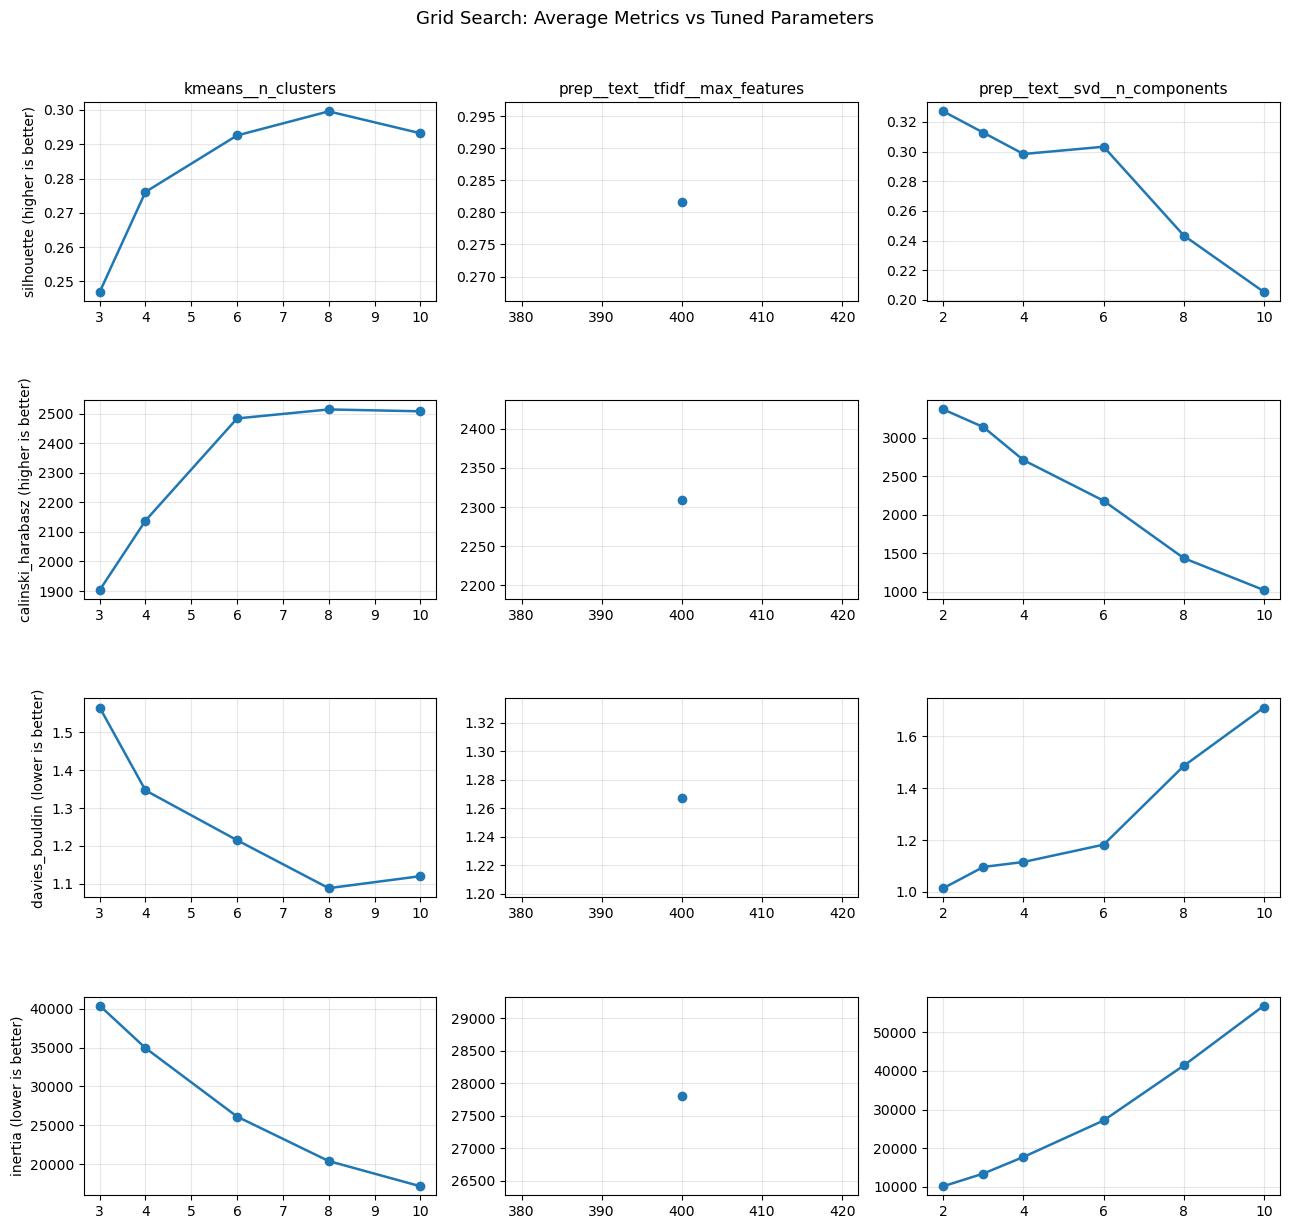



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin


  - 3D plot for metric: inertia




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.01 min
- 3D metric plots: 0.14 min

Total runtime: 0.16 minutes.


In [121]:
# Run grid evaluator on grid search results for renos

grid_evaluator(renos_grid_search_results_03) # Run grid evaluator on grid search results for renos


In [122]:
# Save grid search results to csv

save_grid_results_csv(
    results_df=renos_grid_search_results_03,
    param_grid=reno_params_grid_03,
    filename = "03_kmeans_grid_results_renos.csv"
)

Saved grid results to: C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS/03_kmeans_grid_results_renos.csv


## Clustering with Gaussian Mixture Models

### GMM Pipeline Set Up

In [124]:
# Set up GMM pipeline

gmm = GaussianMixture(
    n_components=4,          # Will tune this
    covariance_type="diag",  # to try: "full", "tied", "diag", "spherical"
    n_init=5,                # multiple restarts like KMeans
    max_iter=500,
    tol=1e-3,
    reg_covar=1e-6,
    random_state=42,
    init_params="kmeans",    # good default
    verbose=0
)

gmm_pipeline = Pipeline([
    ("prep", preprocess),
    ("gmm", gmm),
])

In [125]:
# Fit GMM pipeline

fitted_gmm = gmm_pipeline.fit(cluster_renos_df)

In [126]:
# Test all cluster evaluation tools for GMM

full_evaluator(fitted_gmm, cluster_renos_df)



Extracting all tokens from tf-idf vectorizer...


Number of tokens: 3000


List of 100 random tokens:

 ['exterior deck', 'strata', 'steel', 'building building', 'minor interior', 'update exist', 'bed', 'sprinklered trigger', 'door update', 'ceiling exist', 'millwork plumbing', 'bath area', 'bathroom replace', 'natural', 'closet master', 'building envelope', 'wall master', 'drywall ceiling', 'box base', 'construct interior', 'fixture field', 'additional upgrading', 'replacement exist', 'reconfigure layout', 'window remove', 'component', 'kitchen basement', 'wall closet', 'efficiency upgrade', 'balcony enclosure', 'clearance', 'exterior', 'create', 'improvement add', 'exist multi', 'duct', 'cellar floor', 'bear', 'floor window', 'suite add', 'received owner', 'lot', 'secondary suite', 'finish fixtures', 'damage floor', 'renovate floor', 'improvement level', 'door bathroom', 'renovate kitchen', 'antenna', 'bathroom exist', 'wide high', 'roof membrane', 'add bathroom', 'apply', 'exhaust

Inertia Score (lower better)                       NaN
Silhouette Score (higher better)              0.211597
Calinski Harabasz Index (higher better)    1162.625437
Davies Bouldin Index (lower better)           1.761918
dtype: float64



Computing feature averages by cluster...


Our clusters have the following feature means:


   cluster  size  share project_value_mean  duplex_w_secondary_suite  \
0        0  1931  24.5%            $86,649                  0.000000   
1        1  1457  18.5%            $61,002                  0.005491   
2        2   806  10.2%           $223,961                  0.000000   
3        3  3681  46.7%            $85,372                  0.000000   

   laneway_house  duplex  multiple_conversion_dwelling  dwelling_unit  \
0        0.00000  0.0000                      0.000000       0.000518   
1        0.02059  0.1407                      0.098147       0.000000   
2        0.00000  0.0000                      0.000000       0.480149   
3        0.00000  0.0000                      0.000000       0.000000   

   multiple_dwelling  single_detached_house  \
0           0.000000               1.000000   
1           0.000000               0.040494   
2           0.337469               0.0



=== Step runtimes (minutes) ===
- Extracting all tokens: 0.00 min
- Top tokens per SVD component: 0.00 min
- Overall metrics: 0.93 min
- Cluster averages: 0.90 min
- Top tokens per cluster: 1.77 min
- 3D visualization: 1.86 min

Total runtime: 5.46 minutes.


#### Testing Individual Cluster Evaluators

In [98]:
# Test token extraction function with GMM

extract_tokens(fitted_gmm);

Number of tokens: 3000


List of 100 random tokens:

 ['multiple building', 'comfort letter', 'stratum title', 'basement field', 'attic insulation', 'unapproved', 'crawlspace habitable', 'have vehicle', 'flush', 'kitchen bedroom', 'new car', 'project discretion', 'discretion additional', 'determine onsite', 'add window', 'bathrooms new', 'basement stratum', 'garage remove', 'thereof', 'standard', 'create bedroom', 'mount aluminum', 'discontinue domestic', 'kitchen exist', 'canopy', 'demise', 'paint match', 'screen', 'door enclose', 'structural upgrade', 'update exist', 'finish plumb', 'powder', 'door storage', 'control unit', 'space remove', 'building dedicate', 'repair exterior', 'aluminum cover', 'responsibility final', 'new sink', 'build upgrade', 'validation', 'field timer', 'hardwood', 'space access', 'sleep unit', 'detach accessory', 'family corner', 'removal replacement', 'box base', 'address post', 'remove exist', 'door replacement', 'tree protect', 'minor alteration', 'move', 

In [99]:
# Test SVD top tokens function with GMM

svd_top_tokens(fitted_gmm)

Number of SVD components is: 8


Influential tokens for first 5 components are as follows:

Component 0: floor, unit, multiple building, direct, direct alteration, multiple, improvement unit, unit floor, alteration improvement, improvement
Component 1: suite, secondary, secondary suite, family, access, family secondary, law, new, basement, building law
Component 2: direct alteration, direct, secondary, suite, secondary suite, floor multiple, access, family secondary, improvement unit, building law
Component 3: stage, support document, document, applicable, support, energy upgrade, electrical plumbing, applicable related, longer support, currently longer
Component 4: repair, deck, damage, exterior, direct, window, exist family, direct alteration, roof, replace


In [100]:
# Test overall metrics function with GMM

overall_cluster_metrics(fitted_gmm,cluster_renos_df, gmm = True)

Inertia Score (lower better)                         NaN
Silhouette Score (higher better)                0.161002
Calinski Harabasz Index (higher better)       909.169174
Davies Bouldin Index (lower better)             1.908464
AIC (lower better)                        -382809.934984
BIC (lower better)                        -381840.903648
dtype: float64

Inertia Score (lower better)                         NaN
Silhouette Score (higher better)                0.161002
Calinski Harabasz Index (higher better)       909.169174
Davies Bouldin Index (lower better)             1.908464
AIC (lower better)                        -382809.934984
BIC (lower better)                        -381840.903648
dtype: float64

In [101]:
# Test cluster summaries with GMM

cluster_averages(fitted_gmm, cluster_renos_df)

,cluster,size,share,project_value_mean,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite,silhouette
0,0,2355,29.9%,"$91,350",0.000000,0.012739,0.087049,0.060297,0.000425,0.000000,0.835669,0.000000,0.348
1,1,3668,46.6%,"$111,391",0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.052
2,2,1044,13.3%,"$59,312",0.007663,0.000000,0.000000,0.000958,0.000000,0.000000,0.021073,0.992337,0.256
3,3,808,10.3%,"$80,855",0.000000,0.000000,0.000000,0.000000,0.478960,0.352723,0.000000,0.000000,-0.012


In [102]:
# Test top ten token function with GMM

top_tokens_per_cluster(fitted_gmm,cluster_renos_df)


Top 10 tokens for cluster 0
       token    score  rank
         new 0.619533     1
      family 0.609766     2
       floor 0.602548     3
      remove 0.481104     4
    interior 0.453928     5
exist family 0.409766     6
    building 0.393206     7
       field 0.374947     8
        door 0.355414     9
        wall 0.351592    10

Top 10 tokens for cluster 1
            token    score  rank
             unit 0.850055     1
            floor 0.833424     2
         building 0.732007     3
         multiple 0.717285     4
   exist multiple 0.575245     5
              new 0.553435     6
          kitchen 0.514722     7
             wall 0.509269     8
multiple building 0.452017     9
      improvement 0.431843    10

Top 10 tokens for cluster 2
           token    score  rank
           suite 2.568966     1
       secondary 1.963602     2
 secondary suite 1.924330     3
          family 1.575670     4
        building 1.114943     5
family secondary 1.068966     6
          access 1

,cluster,token,score,rank
0,0,new,0.619533,1
1,0,family,0.609766,2
2,0,floor,0.602548,3
3,0,remove,0.481104,4
4,0,interior,0.453928,5
5,0,exist family,0.409766,6
6,0,building,0.393206,7
7,0,field,0.374947,8
8,0,door,0.355414,9
9,0,wall,0.351592,10


In [103]:
# Test 3D cluster visualization with GMM

plot_clusters_3d(fitted_gmm, cluster_renos_df)

### Grid Searches

#### Builds

##### Grid Search 01

In [108]:
# Choose a starter parameter grid
grid_gmm_small = {
    "gmm__n_components": [3,5,7],
    "gmm__covariance_type": ["diag", "full"],
    "gmm__reg_covar": [1e-6, 1e-4],
    "gmm__n_init": [3],  # keep low for speed
    "prep__text__tfidf__max_features": [400],   # keep vocab modest
    "prep__text__svd__n_components": [5, 10], # compact embeddings
}


In [109]:
# Run starter GMM grid search on builds df

gmm_grid_builds = run_cluster_grid(gmm_pipeline, cluster_builds_df, grid_gmm_small)



[1/24] {'gmm__covariance_type': 'diag', 'gmm__n_components': 3, 'gmm__n_init': 3, 'gmm__reg_covar': 1e-06, 'prep__text__svd__n_components': 5, 'prep__text__tfidf__max_features': 400} | sil=0.1776  CH=1337.0  DB=1.869  Ine=NA  BIC=-542487  AIC=-543189  LL=28.708  runtime=1.00min


[2/24] {'gmm__covariance_type': 'diag', 'gmm__n_components': 3, 'gmm__n_init': 3, 'gmm__reg_covar': 1e-06, 'prep__text__svd__n_components': 10, 'prep__text__tfidf__max_features': 400} | sil=0.1735  CH=1304.7  DB=2.090  Ine=NA  BIC=-491428  AIC=-492344  LL=26.025  runtime=1.07min


[3/24] {'gmm__covariance_type': 'diag', 'gmm__n_components': 3, 'gmm__n_init': 3, 'gmm__reg_covar': 0.0001, 'prep__text__svd__n_components': 5, 'prep__text__tfidf__max_features': 400} | sil=0.1758  CH=1341.3  DB=1.881  Ine=NA  BIC=-266285  AIC=-266986  LL=14.116  runtime=1.05min


[4/24] {'gmm__covariance_type': 'diag', 'gmm__n_components': 3, 'gmm__n_init': 3, 'gmm__reg_covar': 0.0001, 'prep__text__svd__n_components': 10, 'prep__t



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: silhouette  (higher is better)
  • silhouette=0.2056  | gmm__covariance_type=full, gmm__n_components=7, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__svd__n_components=10, prep__text__tfidf__max_features=400, aic=-436912.52486153686, bic=-424247.7316435218, avg_loglik=23.26989248000512  | time=1.07 min

Metric: calinski_harabasz  (higher is better)
  • calinski_harabasz=1384.8819  | gmm__covariance_type=full, gmm__n_components=3, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__svd__n_components=5, prep__text__tfidf__max_features=400, aic=-282467.7397378982, bic=-279190.63505210675, avg_loglik=14.971668413878817  | time=1.00 min

Metric: davies_bouldin  (lower is better)
  • davies_bouldin=1.6271  | gmm__covariance_type=diag, gmm__n_components=5, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=5, prep__text__tfidf__max_features=400, aic=-709016.86587176

KeyError: "['kmeans__n_clusters'] not in index"

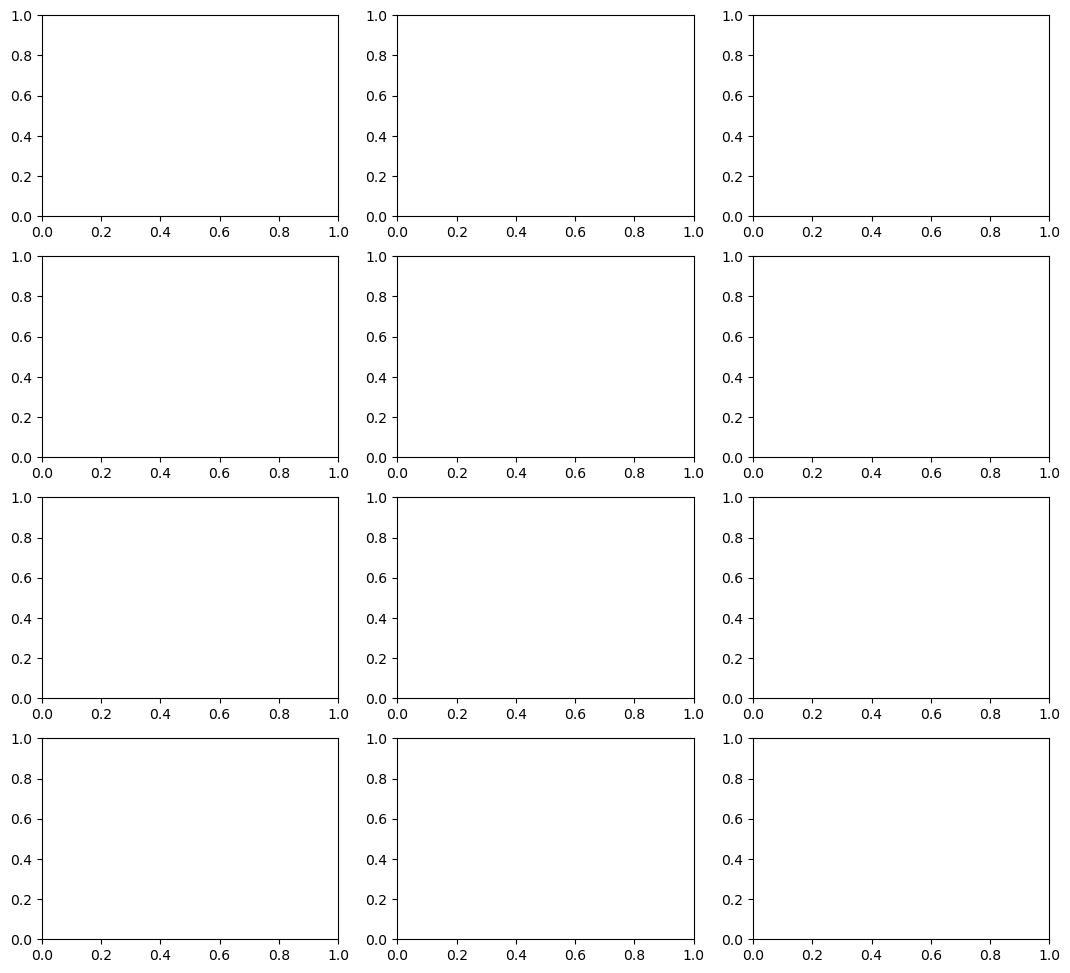

In [123]:
# Run grid evaluator on first GMM grid search results

grid_evaluator(gmm_grid_builds)

In [117]:
# Save first GMM grid search on builds as a csv

save_grid_results_csv(
    results_df=gmm_grid_builds,
    param_grid=grid_gmm_small,
    filename = "/BUILDS/01_gmm_grid_results_builds.csv"
)

Saved grid results to: C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS//BUILDS/01_gmm_grid_results_builds.csv


##### Grid Search 02

In [141]:
# Choose a starter parameter grid
grid_gmm_builds_02 = {
    "gmm__n_components": [3,4,5,6,7,8,10],
    "gmm__covariance_type": ["full"],
    "gmm__reg_covar": [1e-4],
    "gmm__n_init": [3],  # keep low for speed
    "prep__text__tfidf__max_features": [300, 400],   # keep vocab modest
    "prep__text__svd__n_components": [2,4,6,10,15,20], # compact embeddings
}


In [142]:
# Run starter GMM grid search on builds df

gmm_grid_builds_results_02 = run_cluster_grid(gmm_pipeline, cluster_builds_df, grid_gmm_builds_02)



[1/84] {'gmm__covariance_type': 'full', 'gmm__n_components': 3, 'gmm__n_init': 3, 'gmm__reg_covar': 0.0001, 'prep__text__svd__n_components': 2, 'prep__text__tfidf__max_features': 300} | sil=0.1631  CH=1319.2  DB=2.056  Ine=NA  BIC=-462462  AIC=-464709  LL=24.585  runtime=1.00min


[2/84] {'gmm__covariance_type': 'full', 'gmm__n_components': 3, 'gmm__n_init': 3, 'gmm__reg_covar': 0.0001, 'prep__text__svd__n_components': 2, 'prep__text__tfidf__max_features': 400} | sil=0.1960  CH=1608.9  DB=1.728  Ine=NA  BIC=-426174  AIC=-428421  LL=22.667  runtime=0.97min


[3/84] {'gmm__covariance_type': 'full', 'gmm__n_components': 3, 'gmm__n_init': 3, 'gmm__reg_covar': 0.0001, 'prep__text__svd__n_components': 4, 'prep__text__tfidf__max_features': 300} | sil=0.2560  CH=1987.7  DB=1.522  Ine=NA  BIC=-430463  AIC=-433375  LL=22.939  runtime=0.97min


[4/84] {'gmm__covariance_type': 'full', 'gmm__n_components': 3, 'gmm__n_init': 3, 'gmm__reg_covar': 0.0001, 'prep__text__svd__n_components': 4, 'prep__t



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: bic  (lower is better)
  • bic=-628535.4877  | gmm__covariance_type=full, gmm__n_components=10, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__svd__n_components=2, prep__text__tfidf__max_features=400, inertia=nan  | time=0.93 min

Metric: aic  (lower is better)
  • aic=-636041.3454  | gmm__covariance_type=full, gmm__n_components=10, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__svd__n_components=2, prep__text__tfidf__max_features=400, inertia=nan  | time=0.93 min

Metric: avg_loglik  (higher is better)
  • avg_loglik=33.7140  | gmm__covariance_type=full, gmm__n_components=10, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__svd__n_components=2, prep__text__tfidf__max_features=400, inertia=nan  | time=0.93 min

Metric: silhouette  (higher is better)
  • silhouette=0.2754  | gmm__covariance_type=full, gmm__n_components=4, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text_

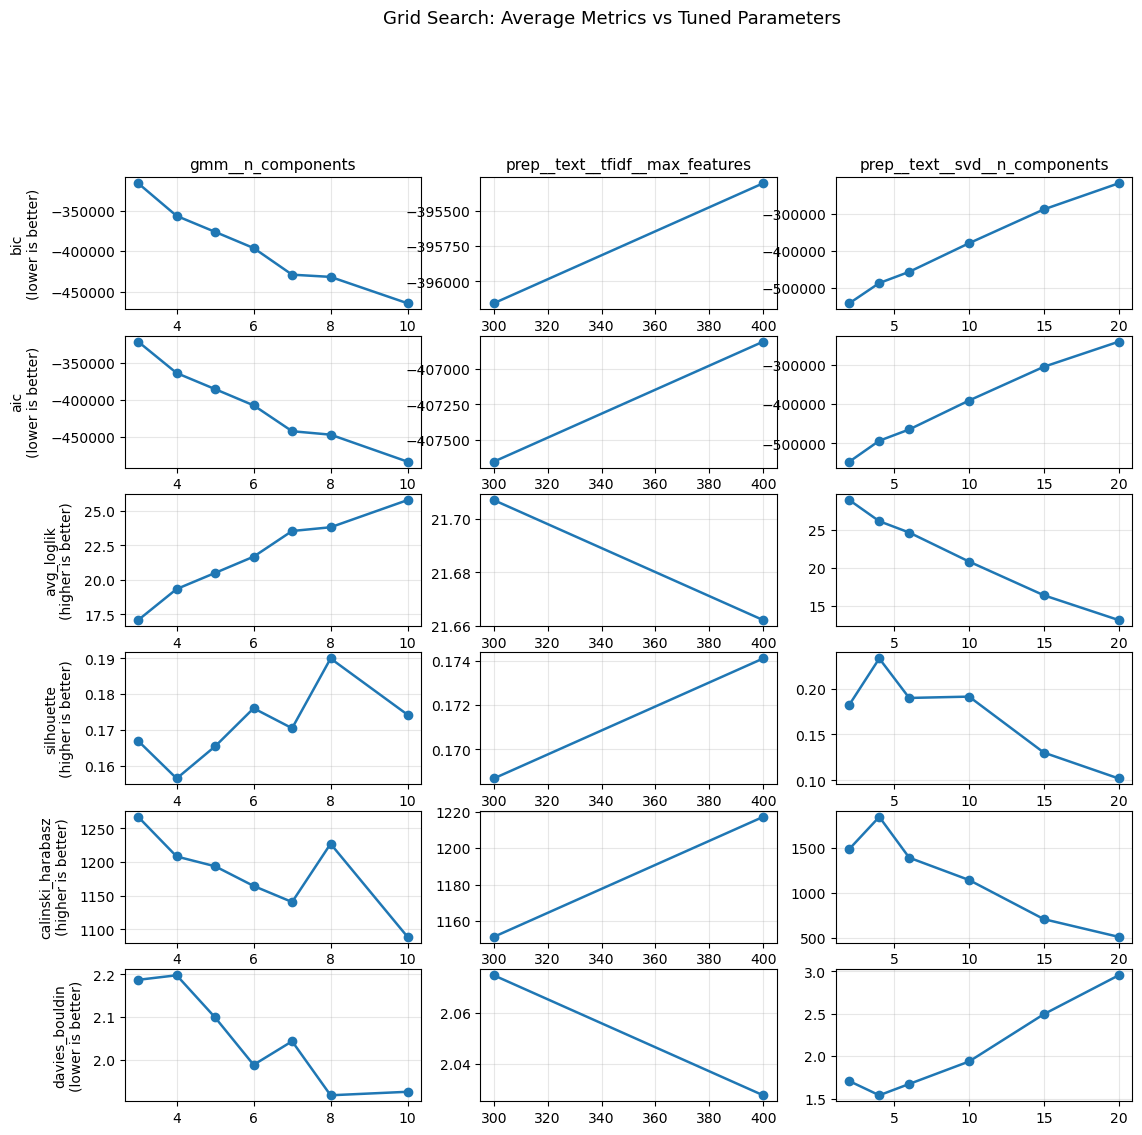



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: bic


  - 3D plot for metric: aic


  - 3D plot for metric: avg_loglik


  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.01 min
- 3D metric plots: 0.21 min

Total runtime: 0.23 minutes.


In [143]:
# Evaluate results

grid_evaluator(gmm_grid_builds_results_02, model = 'gmm')

In [144]:
# Save first GMM grid search on builds as a csv

save_grid_results_csv(
    results_df=gmm_grid_builds_results_02,
    param_grid=grid_gmm_builds_02,
    filename = "/BUILDS/02_gmm_grid_results_builds.csv"
)

Saved grid results to: C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS//BUILDS/02_gmm_grid_results_builds.csv


#### Demolitions

##### Grid Search 01

In [146]:
# Choose a starter parameter grid
params_gmm_demos_01 = {
    "gmm__n_components": [2,3,4,5,6,7,8],
    "gmm__covariance_type": ["full"],
    "gmm__reg_covar": [1e-4],
    "gmm__n_init": [3],  # keep low for speed
    "prep__text__tfidf__max_features": [100,200,300, 400],   # keep vocab modest
    "prep__text__svd__n_components": [2,3,4,5,6,10,15,20], # compact embeddings
}


In [147]:
# Run starter GMM grid search on builds df

gmm_grid_demos_results_01 = run_cluster_grid(gmm_pipeline, cluster_demos_df, params_gmm_demos_01)



[1/224] {'gmm__covariance_type': 'full', 'gmm__n_components': 2, 'gmm__n_init': 3, 'gmm__reg_covar': 0.0001, 'prep__text__svd__n_components': 2, 'prep__text__tfidf__max_features': 100} | sil=0.5394  CH=3540.0  DB=0.724  Ine=NA  BIC=-88407  AIC=-89438  LL=7.853  runtime=0.19min


[2/224] {'gmm__covariance_type': 'full', 'gmm__n_components': 2, 'gmm__n_init': 3, 'gmm__reg_covar': 0.0001, 'prep__text__svd__n_components': 2, 'prep__text__tfidf__max_features': 200} | sil=0.5314  CH=3309.1  DB=0.728  Ine=NA  BIC=-84004  AIC=-85035  LL=7.468  runtime=0.20min


[3/224] {'gmm__covariance_type': 'full', 'gmm__n_components': 2, 'gmm__n_init': 3, 'gmm__reg_covar': 0.0001, 'prep__text__svd__n_components': 2, 'prep__text__tfidf__max_features': 300} | sil=0.1103  CH=300.8  DB=2.295  Ine=NA  BIC=-171192  AIC=-172223  LL=15.097  runtime=0.18min


[4/224] {'gmm__covariance_type': 'full', 'gmm__n_components': 2, 'gmm__n_init': 3, 'gmm__reg_covar': 0.0001, 'prep__text__svd__n_components': 2, 'prep__text



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: bic  (lower is better)
  • bic=-491177.7985  | gmm__covariance_type=full, gmm__n_components=8, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__svd__n_components=20, prep__text__tfidf__max_features=200, inertia=nan  | time=0.19 min

Metric: aic  (lower is better)
  • aic=-515911.6573  | gmm__covariance_type=full, gmm__n_components=8, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__svd__n_components=20, prep__text__tfidf__max_features=200, inertia=nan  | time=0.19 min

Metric: avg_loglik  (higher is better)
  • avg_loglik=45.7954  | gmm__covariance_type=full, gmm__n_components=8, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__svd__n_components=20, prep__text__tfidf__max_features=200, inertia=nan  | time=0.19 min

Metric: silhouette  (higher is better)
  • silhouette=0.5520  | gmm__covariance_type=full, gmm__n_components=7, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text_

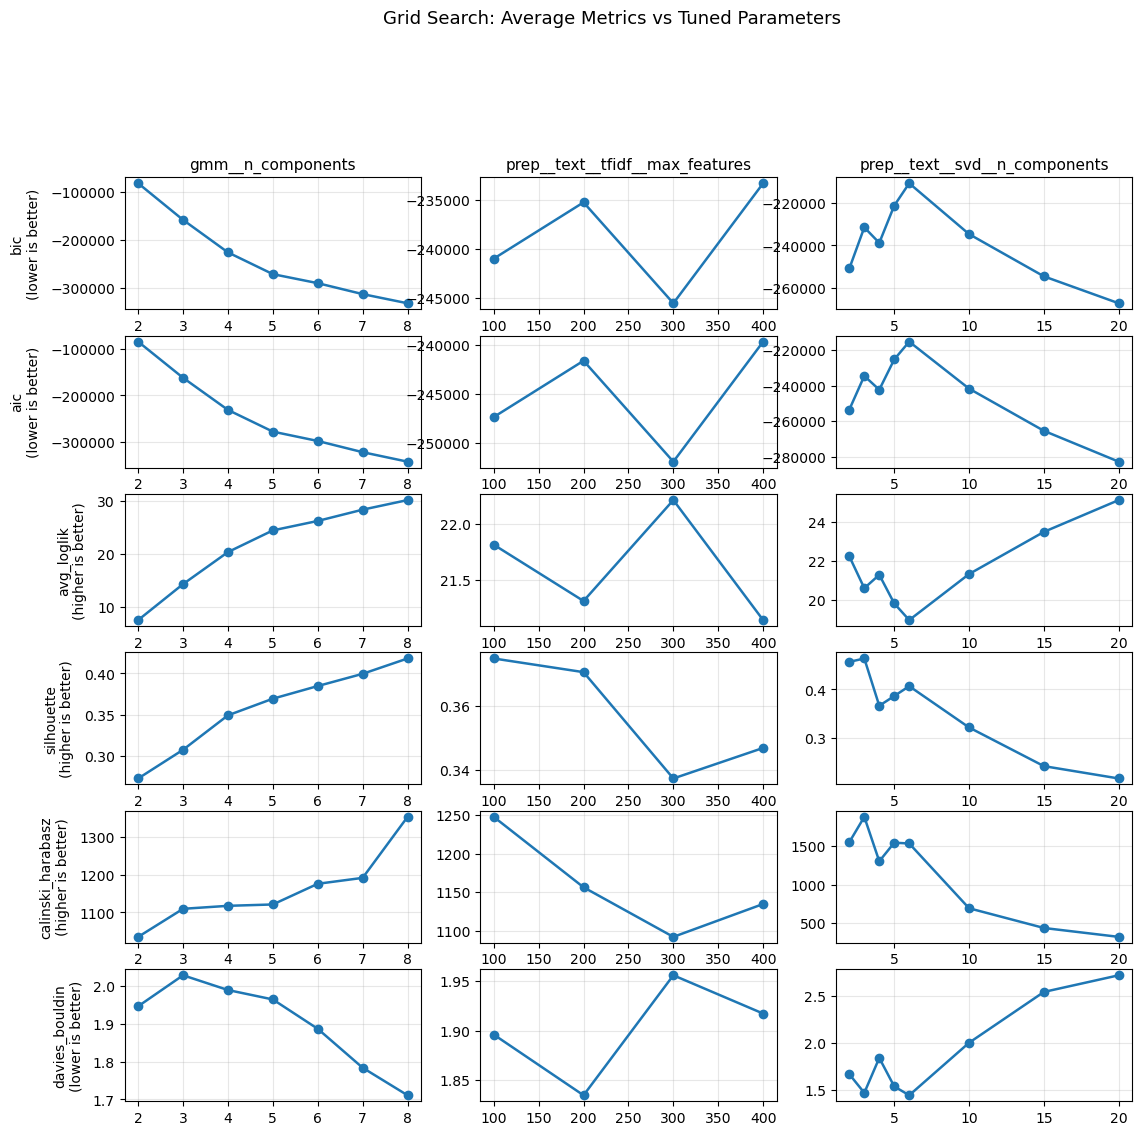



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: bic


  - 3D plot for metric: aic


  - 3D plot for metric: avg_loglik


  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.02 min
- 3D metric plots: 0.21 min

Total runtime: 0.23 minutes.


In [149]:
# Evaluate results

grid_evaluator(gmm_grid_demos_results_01, model = 'gmm')

In [151]:
# Save first GMM grid search on demos as a csv

save_grid_results_csv(
    results_df=gmm_grid_demos_results_01,
    param_grid=params_gmm_demos_01,
    filename = "/DEMOS/01_gmm_grid_results_demos.csv"
)

Saved grid results to: C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS//DEMOS/01_gmm_grid_results_demos.csv


#### Renovations

In [125]:
# Choose a starter parameter grid for renos

grid_gmm_renos_01 = {
    "gmm__n_components": [2,3,4,5,7,10],
    "gmm__covariance_type": ["diag", "full"],
    "gmm__reg_covar": [1e-6, 1e-4],
    "gmm__n_init": [3],  # keep low for speed
    "prep__text__tfidf__max_features": [500],   # keep vocab modest
    "prep__text__svd__n_components": [2,4,6,10,20], # compact embeddings
}


In [126]:
# Run starter GMM grid search on renos df

gmm_grid_results_renos_01 = run_cluster_grid(gmm_pipeline, cluster_renos_df, grid_gmm_renos_01)



[1/120] {'gmm__covariance_type': 'diag', 'gmm__n_components': 2, 'gmm__n_init': 3, 'gmm__reg_covar': 1e-06, 'prep__text__svd__n_components': 2, 'prep__text__tfidf__max_features': 500} | sil=0.3143  CH=2734.7  DB=1.327  Ine=NA  BIC=-316483  AIC=-316797  LL=20.120  runtime=0.53min


[2/120] {'gmm__covariance_type': 'diag', 'gmm__n_components': 2, 'gmm__n_init': 3, 'gmm__reg_covar': 1e-06, 'prep__text__svd__n_components': 4, 'prep__text__tfidf__max_features': 500} | sil=0.2275  CH=1794.2  DB=1.740  Ine=NA  BIC=-272669  AIC=-273039  LL=17.343  runtime=0.48min


[3/120] {'gmm__covariance_type': 'diag', 'gmm__n_components': 2, 'gmm__n_init': 3, 'gmm__reg_covar': 1e-06, 'prep__text__svd__n_components': 6, 'prep__text__tfidf__max_features': 500} | sil=0.1983  CH=1475.1  DB=1.972  Ine=NA  BIC=-230192  AIC=-230618  LL=14.650  runtime=0.51min


[4/120] {'gmm__covariance_type': 'diag', 'gmm__n_components': 2, 'gmm__n_init': 3, 'gmm__reg_covar': 1e-06, 'prep__text__svd__n_components': 10, 'prep__



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: bic  (lower is better)
  • bic=-664071.6949  | gmm__covariance_type=diag, gmm__n_components=10, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=2, prep__text__tfidf__max_features=500, inertia=nan  | time=0.51 min

Metric: aic  (lower is better)
  • aic=-665668.1566  | gmm__covariance_type=diag, gmm__n_components=10, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=2, prep__text__tfidf__max_features=500, inertia=nan  | time=0.51 min

Metric: avg_loglik  (higher is better)
  • avg_loglik=42.2937  | gmm__covariance_type=diag, gmm__n_components=10, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=2, prep__text__tfidf__max_features=500, inertia=nan  | time=0.51 min

Metric: silhouette  (higher is better)
  • silhouette=0.3414  | gmm__covariance_type=full, gmm__n_components=5, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__sv

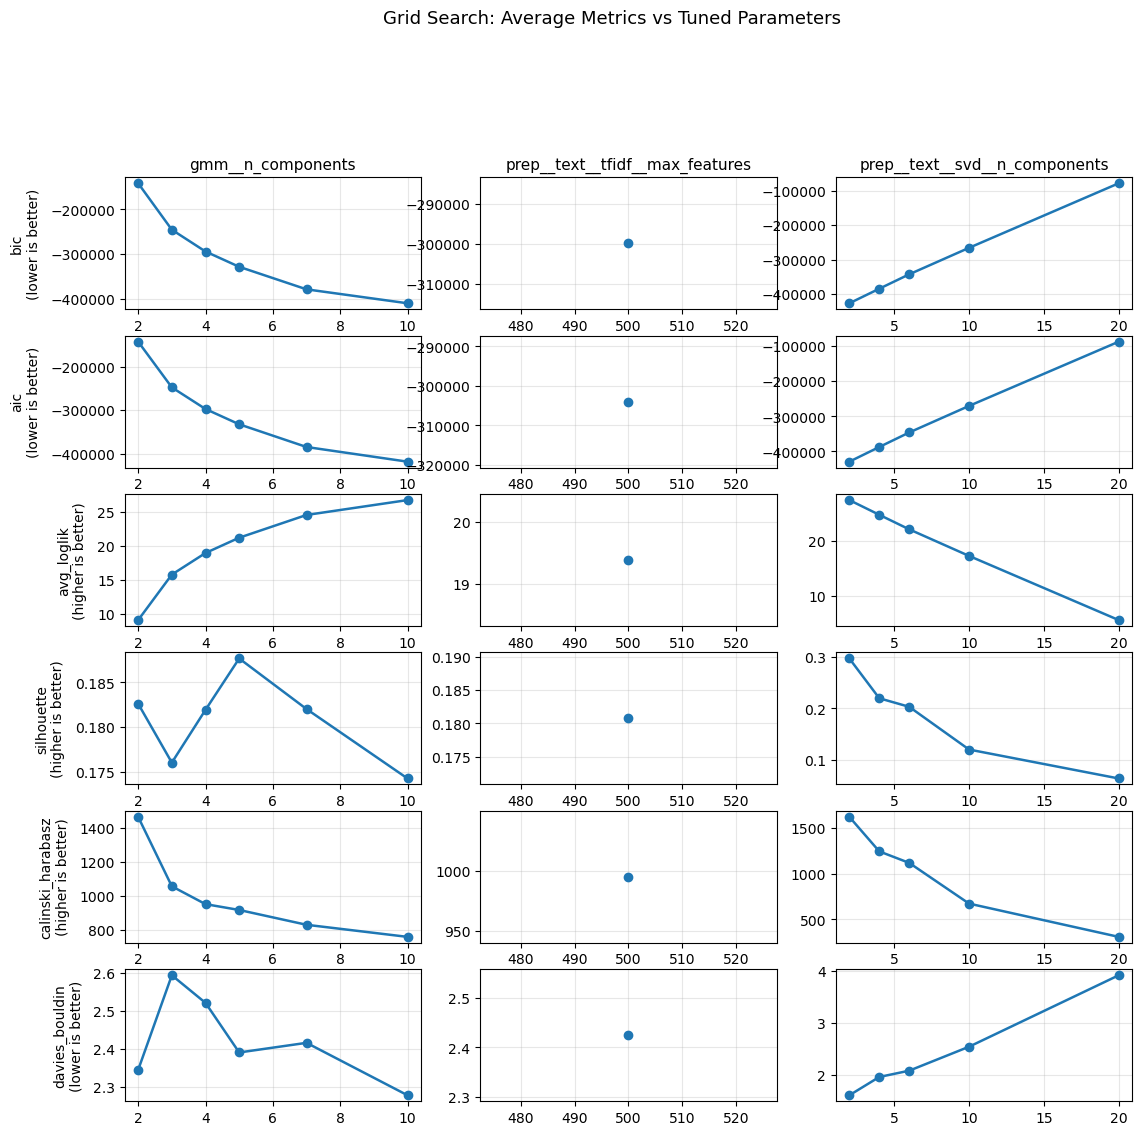



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: bic


  - 3D plot for metric: aic


  - 3D plot for metric: avg_loglik


  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.02 min
- 3D metric plots: 0.21 min

Total runtime: 0.23 minutes.


In [137]:
# Use grid evaluator to check results

grid_evaluator(gmm_grid_results_renos_01, model = 'gmm')

In [139]:
# Save first GMM grid search on builds as a csv

save_grid_results_csv(
    results_df=gmm_grid_results_renos_01,
    param_grid=grid_gmm_renos_01,
    filename = "/RENOS/01_gmm_grid_results_renos.csv"
)

Saved grid results to: C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS//RENOS/01_gmm_grid_results_renos.csv


## Hierarchical (Agglomerative) Clustering

### Agglomerative Clustering Pipeline Set up

In [41]:
agg_pipe = Pipeline(steps=[
    ("prep", preprocess),
    # Toggle this to Normalizer() when using cosine metrics; keep as passthrough for Euclidean/Ward.
    ("norm", "passthrough"),
    ("agg", AgglomerativeClustering(
        n_clusters=10,              # will be tuned
        linkage="ward",             # default; will be tuned
        metric="euclidean",         # ignored for ward; will be tuned for non-ward
        compute_distances=True      # enables dendrogram plotting later
    ))
])

In [65]:
# Run full agglomerative clustering pipeline

start = time.time()
fitted_agg_pipe = agg_pipe.fit(cluster_demos_df)
elapsed = time.time() - start
mins = elapsed / 60
print(f"\n\nAgglomerative pipeline fit runtime: {mins:.2f} minutes.")




Agglomerative pipeline fit runtime: 0.17 minutes.


In [123]:
# Test all cluster evaluation tools for agg

full_evaluator(fitted_agglom_pipe, cluster_demos_df)



Extracting all tokens from tf-idf vectorizer...


Number of tokens: 408


List of 100 random tokens:

 ['single detach', 'character', 'energy bylaw', 'law deposit', 'exist multiple', 'form copy', 'low demo', 'deconstruction canadian', 'law', 'compliancereport', 'deconstruction subject', 'family deconstruction', 'order date', 'family build', 'hazardous construction', 'low recycle', 'demolition', 'construct', 'canadian', 'separate', 'confirm acceptable', 'associate', 'deconstruction hour', 'copy recycle', 'reuse', 'building subject', 'change', 'non hazardous', 'green law', 'inspection', 'excavate demolition', 'build', 'rezoning', 'recycling sign', 'outside shore', 'outside', 'demolish grade', 'directly online', 'exist mixed', 'apply', 'exist building', 'contractor phone', 'acceptable', 'building grade', 'multiple building', 'service', 'energy', 'related salvage', 'exist grade', 'recycling update', 'retail', 'parking', 'right', 'memo', 'mixed', 'car', 'salvage', 'associate green', 'rela

Inertia Score (lower better)                       NaN
Silhouette Score (higher better)              0.613991
Calinski Harabasz Index (higher better)    4341.937035
Davies Bouldin Index (lower better)           0.630353
dtype: float64



Computing feature averages by cluster...


Our clusters have the following feature means:


   cluster  size  share project_value_mean  duplex_w_secondary_suite  \
0        0  1149  20.1%            $25,366                  0.018277   
1        1   506   8.9%            $20,126                  0.001976   
2        2     3   0.1%         $4,648,644                  0.000000   
3        3   631  11.0%            $17,683                  0.017433   
4        4   643  11.3%            $36,742                  0.000000   
5        5   915  16.0%            $17,377                  0.031694   
6        6   572  10.0%            $17,167                  0.071678   
7        7   389   6.8%            $15,868                  0.017995   
8        8    29   0.5%           $658,552                  0.000000   
9        9   877  15.3%            $16,922                  0.000000   

   laneway_house    duplex  multiple_conversion_dwelling  dwelling_unit  \
0       0.005222  0.044386            



=== Step runtimes (minutes) ===
- Extracting all tokens: 0.00 min
- Top tokens per SVD component: 0.00 min
- Overall metrics: 0.33 min
- Cluster averages: 0.35 min
- Top tokens per cluster: 0.66 min
- 3D visualization: 0.64 min

Total runtime: 1.98 minutes.


#### Testing Individual Cluster Evaluators

In [49]:
# Test token extraction function with agg

extract_tokens(fitted_agglom_pipe);

Number of tokens: 408


List of 100 random tokens:

 ['recycling tonne', 'mixed use', 'inspection', 'great', 'right', 'uploaded', 'waste contractor', 'post', 'waste', 'mean green', 'excavation', 'house building', 'indicated survey', 'demo', 'drawing', 'city', 'demolition relate', 'building hour', 'reuse', 'updated energy', 'apply', 'accessory', 'exist build', 'lot', 'compliancereport', 'deconstruction hour', 'family demo', 'underground parking', 'shore ready', 'energy', 'detach garage', 'build hour', 'energy bylaw', 'shore separate', 'email', 'effective', 'subject green', 'build contractor', 'phone number', 'associate', 'low demolish', 'finalized', 'family hour', 'recycle reuse', 'house build', 'building processing', 'detach home', 'deconstruction build', 'green', 'waste subject', 'demolition call', 'building subject', 'report', 'call outside', 'grade recycle', 'demolition contractor', 'ready conduct', 'retain', 'assess pre', 'soil incidental', 'build recycle', 'recycling sign', 'email

In [50]:
# Test SVD top tokens function with agg

svd_top_tokens(fitted_agglom_pipe)

Number of SVD components is: 5


Influential tokens for first 5 components are as follows:

Component 0: low demolish, family building, mean deconstruction, building mean, mean, deconstruction, subject green, green, subject, deconstruction subject
Component 1: mean deconstruction, building mean, mean, deconstruction, subject green, green, subject, deconstruction subject, recycle, recycle non
Component 2: recycling, green recycling, recycle subject, deconstruction recycle, mean deconstruction, mean, building mean, bylaw effective, bylaw, energy bylaw
Component 3: demolition, soil, recycle, grade, receipt, call, hour, advance demolition, demolition call, advance
Component 4: bylaw effective, bylaw, effective, energy, energy bylaw, update energy, update, building update, green update, recycle non


In [52]:
# Test overall metrics function with agg

overall_cluster_metrics(fitted_agglom_pipe,cluster_demos_df)

Inertia Score (lower better)                       NaN
Silhouette Score (higher better)              0.613991
Calinski Harabasz Index (higher better)    4341.937035
Davies Bouldin Index (lower better)           0.630353
dtype: float64

Inertia Score (lower better)                       NaN
Silhouette Score (higher better)              0.613991
Calinski Harabasz Index (higher better)    4341.937035
Davies Bouldin Index (lower better)           0.630353
dtype: float64

In [54]:
# Test cluster summaries with agg

cluster_averages(fitted_agglom_pipe, cluster_demos_df)

,cluster,size,share,project_value_mean,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite,silhouette
0,0,1149,20.1%,"$25,366",0.018277,0.005222,0.044386,0.004352,0.021758,0.044386,0.646649,0.202785,0.372
1,1,506,8.9%,"$20,126",0.001976,0.005929,0.009881,0.001976,0.029644,0.000000,0.926877,0.019763,0.529
2,2,3,0.1%,"$4,648,644",0.000000,0.000000,0.000000,0.000000,0.000000,0.666667,0.000000,0.000000,0.518
3,3,631,11.0%,"$17,683",0.017433,0.000000,0.042789,0.000000,0.003170,0.000000,0.811410,0.125198,0.432
4,4,643,11.3%,"$36,742",0.000000,0.004666,0.060653,0.012442,0.017107,0.038880,0.832037,0.020218,0.572
5,5,915,16.0%,"$17,377",0.031694,0.000000,0.091803,0.000000,0.004372,0.000000,0.580328,0.289617,0.665
6,6,572,10.0%,"$17,167",0.071678,0.000000,0.110140,0.000000,0.019231,0.000000,0.000000,0.793706,0.643
7,7,389,6.8%,"$15,868",0.017995,0.000000,0.030848,0.000000,0.020566,0.000000,0.850900,0.079692,0.842
8,8,29,0.5%,"$658,552",0.000000,0.000000,0.068966,0.034483,0.068966,0.551724,0.137931,0.034483,0.437
9,9,877,15.3%,"$16,922",0.000000,0.001140,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.975


In [55]:
# Test top ten token function with agg

top_tokens_per_cluster(fitted_agglom_pipe,cluster_demos_df)


Top 10 tokens for cluster 0
          token    score  rank
family building 0.375979     1
   low demolish 0.369887     2
      recycling 0.201915     3
          build 0.174064     4
     demolition 0.137511     5
          green 0.136641     6
     contractor 0.128808     7
        subject 0.118364     8
        recycle 0.116623     9
           demo 0.107920    10

Top 10 tokens for cluster 1
          token    score  rank
      effective 1.000000     1
         energy 1.000000     2
bylaw effective 1.000000     3
   energy bylaw 1.000000     4
          bylaw 1.000000     5
  update energy 0.950593     6
         update 0.950593     7
   low demolish 0.918972     8
family building 0.772727     9
          green 0.707510    10

Top 10 tokens for cluster 2
         token    score  rank
    demolition 1.000000     1
           new 0.666667     2
          zone 0.333333     3
         build 0.333333     4
  construction 0.333333     5
exist multiple 0.333333     6
           law 0.3333

,cluster,token,score,rank
0,0,family building,0.375979,1
1,0,low demolish,0.369887,2
2,0,recycling,0.201915,3
3,0,build,0.174064,4
4,0,demolition,0.137511,5
...,...,...,...,...
95,9,disturbance excavation,0.000000,6
96,9,document,0.000000,7
97,9,directly,0.000000,8
98,9,disposal,0.000000,9


In [56]:
# Test 3D cluster visualization with agg

plot_clusters_3d(fitted_agglom_pipe, cluster_demos_df)

### Grid Searches

#### Builds

##### Grid Search 01

In [81]:
# Choose a starter parameter grid

agg_builds_params_01 = { "agg__n_clusters": [2,3,4,5,6,8],
    "agg__metric": ["euclidean"],
    "agg__distance_threshold": [None], 
    "prep__text__tfidf__max_features": [300],   # keep vocab modest
    "prep__text__svd__n_components": [2,5,10,15,20], # compact embeddings
}

In [82]:
# Run starter agg grid search on builds df

agg_grid_builds_results_01 = run_cluster_grid(agg_pipe, cluster_builds_df, agg_builds_params_01)



[1/30] {'agg__distance_threshold': None, 'agg__metric': 'euclidean', 'agg__n_clusters': 2, 'prep__text__svd__n_components': 2, 'prep__text__tfidf__max_features': 300} | sil=0.2713  CH=3014.6  DB=1.417  Ine=NA  BIC=NA  AIC=NA  LL=NA  runtime=0.91min


[2/30] {'agg__distance_threshold': None, 'agg__metric': 'euclidean', 'agg__n_clusters': 2, 'prep__text__svd__n_components': 5, 'prep__text__tfidf__max_features': 300} | sil=0.1930  CH=1800.2  DB=1.951  Ine=NA  BIC=NA  AIC=NA  LL=NA  runtime=1.84min


[3/30] {'agg__distance_threshold': None, 'agg__metric': 'euclidean', 'agg__n_clusters': 2, 'prep__text__svd__n_components': 10, 'prep__text__tfidf__max_features': 300} | sil=0.2149  CH=1178.9  DB=1.422  Ine=NA  BIC=NA  AIC=NA  LL=NA  runtime=1.74min


[4/30] {'agg__distance_threshold': None, 'agg__metric': 'euclidean', 'agg__n_clusters': 2, 'prep__text__svd__n_components': 15, 'prep__text__tfidf__max_features': 300} | sil=0.2663  CH=823.5  DB=1.143  Ine=NA  BIC=NA  AIC=NA  LL=NA  runtime=1.7

In [84]:
# Save first agg grid search on builds as a csv

save_grid_results_csv(  
    results_df=agg_grid_builds_results_01,
    param_grid=agg_builds_params_01,
    filename = "/BUILDS/AGG/01_agg_grid_results_builds.csv"
)

Saved grid results to: C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS//BUILDS/AGG/01_agg_grid_results_builds.csv


##### Grid Search 02

In [83]:
# Choose a starter parameter grid

agg_builds_params_02 = {"prep__text__tfidf__max_features": [100,300,500],        # modest → medium vocab
    "prep__text__svd__n_components": [3, 4, 5, 6, 8, 10, 12],     # small-ish, centered near your best (=5)
    "agg__n_clusters": [5,6,7,8,9,10,11,12], 
    "agg__linkage": ["ward"],
    "agg__metric": ["euclidean"],                               # required for ward
    "agg__distance_threshold": [None],
}

In [85]:
# Run starter agg grid search on builds df

agg_grid_builds_results_02 = run_cluster_grid(agg_pipe, cluster_builds_df, agg_builds_params_02)



[1/168] {'agg__distance_threshold': None, 'agg__linkage': 'ward', 'agg__metric': 'euclidean', 'agg__n_clusters': 5, 'prep__text__svd__n_components': 3, 'prep__text__tfidf__max_features': 100} | sil=0.3178  CH=3421.3  DB=0.959  Ine=NA  BIC=NA  AIC=NA  LL=NA  runtime=1.87min


[2/168] {'agg__distance_threshold': None, 'agg__linkage': 'ward', 'agg__metric': 'euclidean', 'agg__n_clusters': 5, 'prep__text__svd__n_components': 3, 'prep__text__tfidf__max_features': 300} | sil=0.2974  CH=3105.6  DB=0.924  Ine=NA  BIC=NA  AIC=NA  LL=NA  runtime=1.86min


[3/168] {'agg__distance_threshold': None, 'agg__linkage': 'ward', 'agg__metric': 'euclidean', 'agg__n_clusters': 5, 'prep__text__svd__n_components': 3, 'prep__text__tfidf__max_features': 500} | sil=0.2950  CH=3119.9  DB=0.978  Ine=NA  BIC=NA  AIC=NA  LL=NA  runtime=1.79min


[4/168] {'agg__distance_threshold': None, 'agg__linkage': 'ward', 'agg__metric': 'euclidean', 'agg__n_clusters': 5, 'prep__text__svd__n_components': 4, 'prep__text__tfidf



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: silhouette  (higher is better)
  • silhouette=0.4137  | agg__distance_threshold=None, agg__linkage=ward, agg__metric=euclidean, agg__n_clusters=9, prep__text__svd__n_components=4, prep__text__tfidf__max_features=100, inertia=nan, aic=nan, bic=nan, avg_loglik=nan  | time=1.79 min

Metric: calinski_harabasz  (higher is better)
  • calinski_harabasz=4189.8836  | agg__distance_threshold=None, agg__linkage=ward, agg__metric=euclidean, agg__n_clusters=9, prep__text__svd__n_components=4, prep__text__tfidf__max_features=100, inertia=nan, aic=nan, bic=nan, avg_loglik=nan  | time=1.79 min

Metric: davies_bouldin  (lower is better)
  • davies_bouldin=0.7665  | agg__distance_threshold=None, agg__linkage=ward, agg__metric=euclidean, agg__n_clusters=8, prep__text__svd__n_components=4, prep__text__tfidf__max_features=500, inertia=nan, aic=nan, bic=nan, avg_loglik=nan  | time=1.84 min


Plott

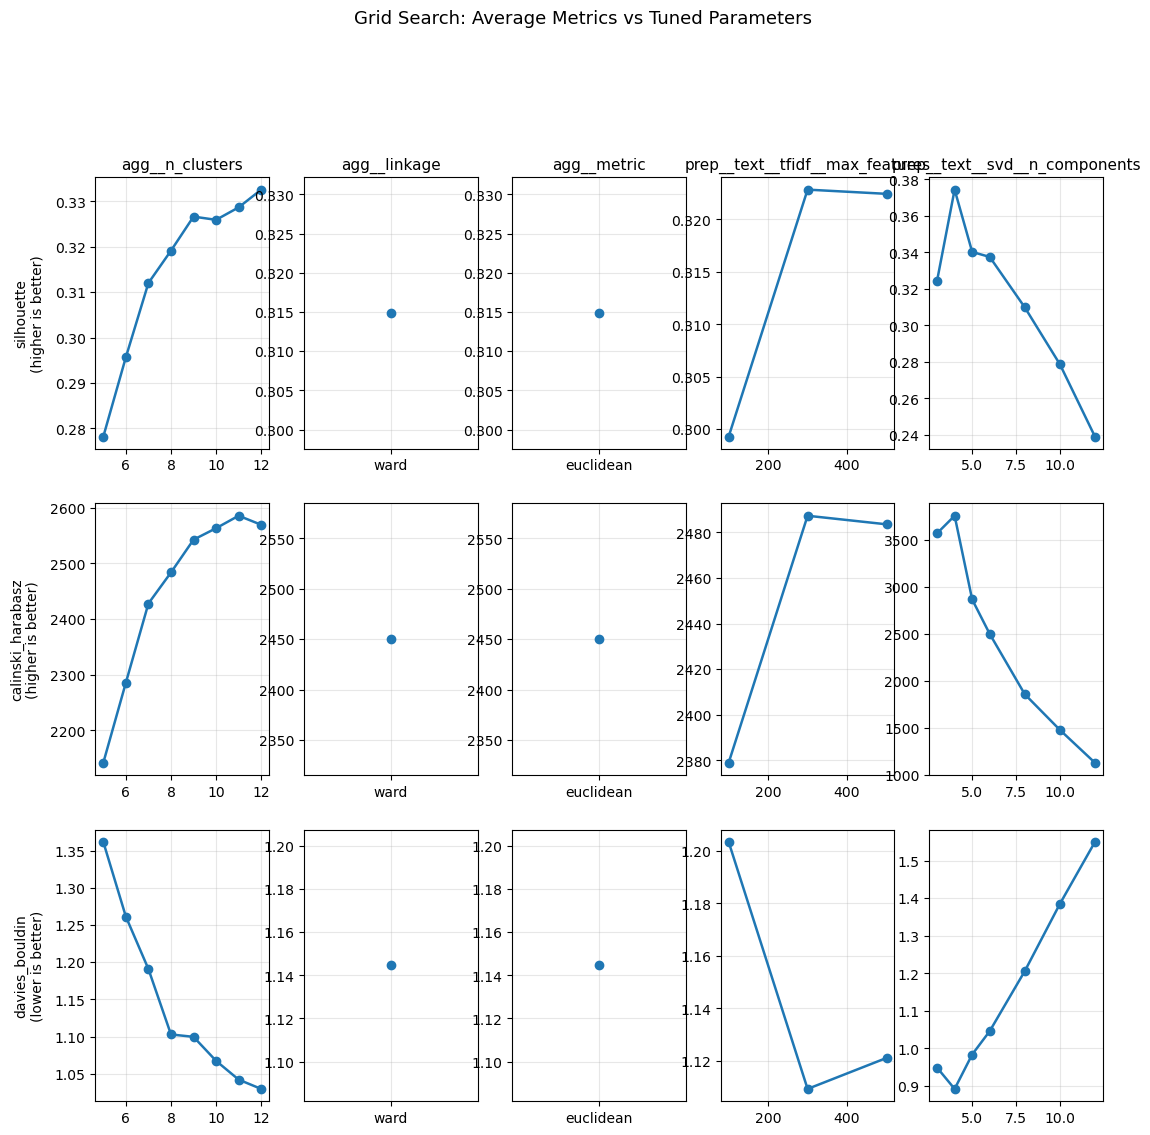



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.02 min
- 3D metric plots: 0.11 min

Total runtime: 0.13 minutes.


In [86]:
# Evaluate grid search results

grid_evaluator(agg_grid_builds_results_02, model = 'agg')

In [87]:
# Save first agg grid search on builds as a csv

save_grid_results_csv(  
    results_df=agg_grid_builds_results_02,
    param_grid=agg_builds_params_02,
    filename = "/BUILDS/AGG/02_agg_grid_results_builds.csv"
)

Saved grid results to: C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS//BUILDS/AGG/02_agg_grid_results_builds.csv


#### Demolitions

In [73]:
# Choose a starter parameter grid

agg_demos_params_01 = { "agg__n_clusters": [2,3,4,6,8],
    "agg__metric": ["euclidean"],
    "agg__distance_threshold": [None], 
    "prep__text__tfidf__max_features": [300],   # keep vocab modest
    "prep__text__svd__n_components": [2,5,10,15,20], # compact embeddings
}

In [74]:
# Run starter agg grid search on demos df

agg_grid_demos_results_01 = run_cluster_grid(agg_pipe, cluster_demos_df, agg_demos_params_01)



[1/25] {'agg__distance_threshold': None, 'agg__metric': 'euclidean', 'agg__n_clusters': 2, 'prep__text__svd__n_components': 2, 'prep__text__tfidf__max_features': 300} | sil=0.5383  CH=3402.9  DB=0.719  Ine=NA  BIC=NA  AIC=NA  LL=NA  runtime=0.17min


[2/25] {'agg__distance_threshold': None, 'agg__metric': 'euclidean', 'agg__n_clusters': 2, 'prep__text__svd__n_components': 5, 'prep__text__tfidf__max_features': 300} | sil=0.3007  CH=1534.9  DB=1.095  Ine=NA  BIC=NA  AIC=NA  LL=NA  runtime=0.16min


[3/25] {'agg__distance_threshold': None, 'agg__metric': 'euclidean', 'agg__n_clusters': 2, 'prep__text__svd__n_components': 10, 'prep__text__tfidf__max_features': 300} | sil=0.1614  CH=785.1  DB=1.446  Ine=NA  BIC=NA  AIC=NA  LL=NA  runtime=0.16min


[4/25] {'agg__distance_threshold': None, 'agg__metric': 'euclidean', 'agg__n_clusters': 2, 'prep__text__svd__n_components': 15, 'prep__text__tfidf__max_features': 300} | sil=0.1041  CH=542.6  DB=1.723  Ine=NA  BIC=NA  AIC=NA  LL=NA  runtime=0.17

In [75]:
# Save first agg grid search on demps as a csv

save_grid_results_csv(
    results_df=agg_grid_demos_results_01,
    param_grid=agg_demos_params_01,
    filename = "/DEMOS/AGG/01_agg_grid_results_demos.csv"
)

Saved grid results to: C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS//DEMOS/AGG/01_agg_grid_results_demos.csv


#### Renovations

In [77]:
# Choose a starter parameter grid

agg_renos_params_01 = { "agg__n_clusters": [2,3,4,5,6,8],
    "agg__metric": ["euclidean"],
    "agg__distance_threshold": [None], 
    "prep__text__tfidf__max_features": [300],   # keep vocab modest
    "prep__text__svd__n_components": [2,5,10,15,20], # compact embeddings
}

In [78]:
# Run starter agg grid search on renos df

agg_grid_renos_results_01 = run_cluster_grid(agg_pipe, cluster_renos_df, agg_renos_params_01)



[1/30] {'agg__distance_threshold': None, 'agg__metric': 'euclidean', 'agg__n_clusters': 2, 'prep__text__svd__n_components': 2, 'prep__text__tfidf__max_features': 300} | sil=0.2793  CH=2809.1  DB=1.079  Ine=NA  BIC=NA  AIC=NA  LL=NA  runtime=0.44min


[2/30] {'agg__distance_threshold': None, 'agg__metric': 'euclidean', 'agg__n_clusters': 2, 'prep__text__svd__n_components': 5, 'prep__text__tfidf__max_features': 300} | sil=0.2348  CH=1882.3  DB=1.740  Ine=NA  BIC=NA  AIC=NA  LL=NA  runtime=0.44min


[3/30] {'agg__distance_threshold': None, 'agg__metric': 'euclidean', 'agg__n_clusters': 2, 'prep__text__svd__n_components': 10, 'prep__text__tfidf__max_features': 300} | sil=0.1184  CH=914.2  DB=2.672  Ine=NA  BIC=NA  AIC=NA  LL=NA  runtime=0.43min


[4/30] {'agg__distance_threshold': None, 'agg__metric': 'euclidean', 'agg__n_clusters': 2, 'prep__text__svd__n_components': 15, 'prep__text__tfidf__max_features': 300} | sil=0.0641  CH=517.0  DB=3.167  Ine=NA  BIC=NA  AIC=NA  LL=NA  runtime=0.47

In [80]:
# Save first agg grid search on demps as a csv

save_grid_results_csv(
    results_df=agg_grid_renos_results_01,
    param_grid=agg_renos_params_01,
    filename = "/RENOS/AGG/01_agg_grid_results_renos.csv"
)

Saved grid results to: C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS//RENOS/AGG/01_agg_grid_results_renos.csv


##### Grid Search 02

In [39]:
# Choose a starter parameter grid

agg_renos_params_02 = {"prep__text__tfidf__max_features": [100,300,500],        # modest → medium vocab
    "prep__text__svd__n_components": [3, 4, 5, 6, 8, 10, 12],     # small-ish, centered near your best (=5)
    "agg__n_clusters": [5,6,7,8,9,10,11,12], 
    "agg__linkage": ["ward"],
    "agg__metric": ["euclidean"],                               # required for ward
    "agg__distance_threshold": [None],
}

In [42]:
# Run starter agg grid search on renos df

agg_grid_renos_results_02 = run_cluster_grid(agg_pipe, cluster_renos_df, agg_renos_params_02)



[1/168] {'agg__distance_threshold': None, 'agg__linkage': 'ward', 'agg__metric': 'euclidean', 'agg__n_clusters': 5, 'prep__text__svd__n_components': 3, 'prep__text__tfidf__max_features': 100} | sil=0.3247  CH=2831.3  DB=0.996  Ine=NA  BIC=NA  AIC=NA  LL=NA  noise=NA  clusters=5  runtime=1.05min


[2/168] {'agg__distance_threshold': None, 'agg__linkage': 'ward', 'agg__metric': 'euclidean', 'agg__n_clusters': 5, 'prep__text__svd__n_components': 3, 'prep__text__tfidf__max_features': 300} | sil=0.3452  CH=3228.2  DB=0.945  Ine=NA  BIC=NA  AIC=NA  LL=NA  noise=NA  clusters=5  runtime=0.93min


[3/168] {'agg__distance_threshold': None, 'agg__linkage': 'ward', 'agg__metric': 'euclidean', 'agg__n_clusters': 5, 'prep__text__svd__n_components': 3, 'prep__text__tfidf__max_features': 500} | sil=0.3047  CH=3111.4  DB=1.009  Ine=NA  BIC=NA  AIC=NA  LL=NA  noise=NA  clusters=5  runtime=0.86min


[4/168] {'agg__distance_threshold': None, 'agg__linkage': 'ward', 'agg__metric': 'euclidean', 'agg__n_cl



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: silhouette  (higher is better)
  • silhouette=0.3524  | agg__distance_threshold=None, agg__linkage=ward, agg__metric=euclidean, agg__n_clusters=6, prep__text__svd__n_components=3, prep__text__tfidf__max_features=300, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, noise_frac=nan  | time=0.88 min

Metric: calinski_harabasz  (higher is better)
  • calinski_harabasz=3228.2083  | agg__distance_threshold=None, agg__linkage=ward, agg__metric=euclidean, agg__n_clusters=5, prep__text__svd__n_components=3, prep__text__tfidf__max_features=300, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, noise_frac=nan  | time=0.93 min

Metric: davies_bouldin  (lower is better)
  • davies_bouldin=0.8237  | agg__distance_threshold=None, agg__linkage=ward, agg__metric=euclidean, agg__n_clusters=6, prep__text__svd__n_components=5, prep__text__tfidf__max_features=500, inertia=nan, aic=nan, bic=nan, avg_log

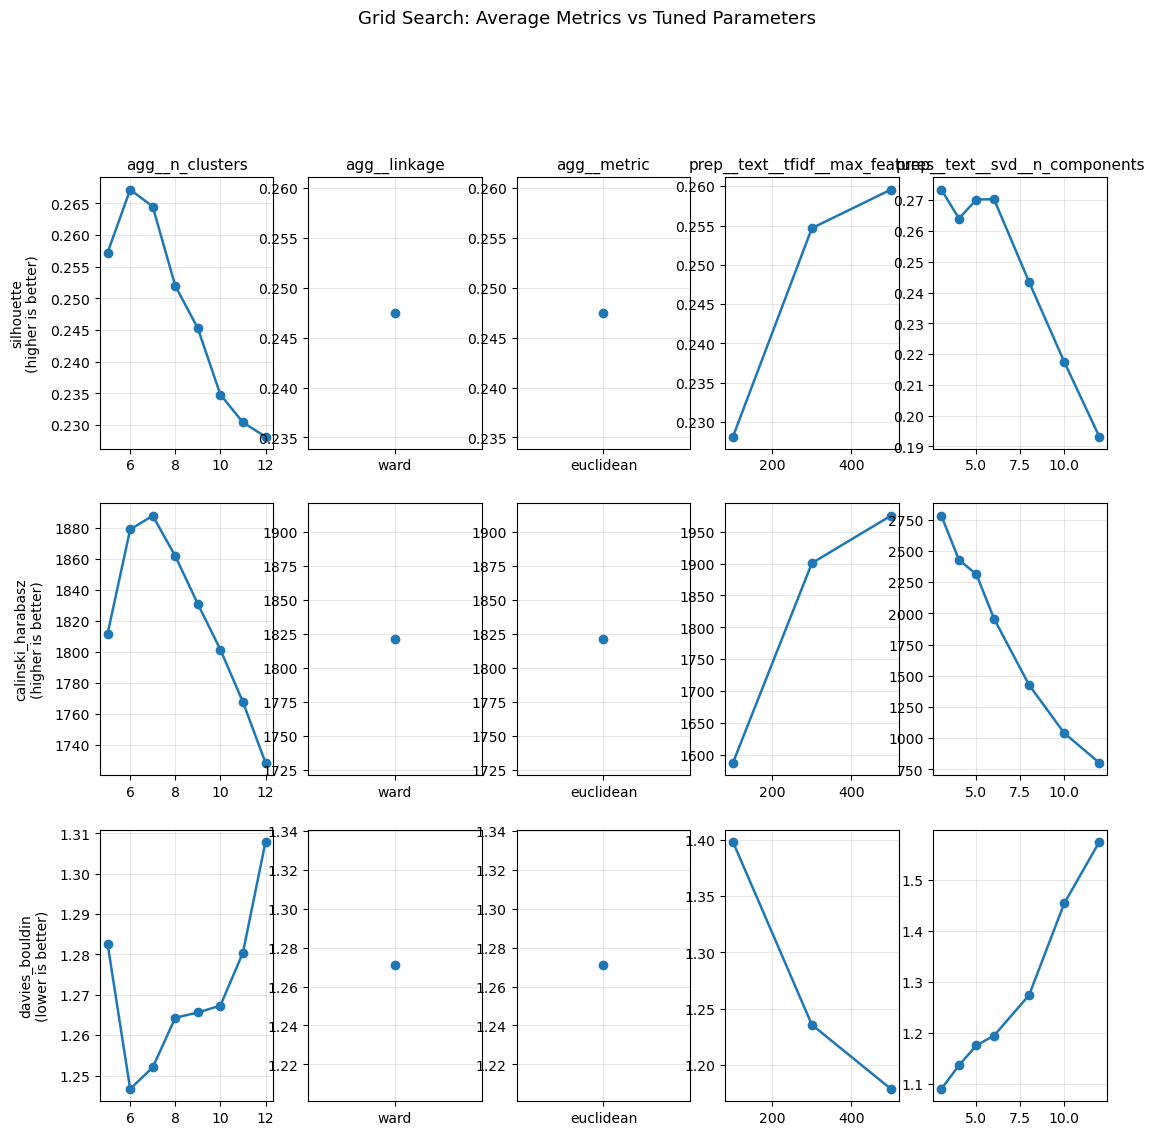



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.02 min
- 3D metric plots: 0.13 min

Total runtime: 0.15 minutes.


In [43]:
# Evaluate grid search results

grid_evaluator(agg_grid_renos_results_02, model = 'agg')

In [44]:
# Save second agg grid search on renos as a csv

save_grid_results_csv(  
    results_df=agg_grid_renos_results_02,
    param_grid=agg_renos_params_02,
    filename = "/RENOS/AGG/02_agg_grid_results_renos.csv"
)

Saved grid results to: C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS//RENOS/AGG/02_agg_grid_results_renos.csv


## Clustering with HDBSCAN

### HDBSCAN Pipeline Set up

In [70]:
# Set up HDBSCAN pipeline

hdbscan_est = hdbscan.HDBSCAN(
    min_cluster_size=100,               # tune
    min_samples=None,                  # defaults to min_cluster_size (robust)
    metric="euclidean",
    cluster_selection_method="eom",    # 'leaf' often yields finer clusters
     cluster_selection_epsilon=0.02,
    prediction_data=True,              # enables approximate_predict later
    core_dist_n_jobs=-1                # parallel core-distance
)

hdbscan_pipe = Pipeline([
    ("prep", preprocess),
    # Global scaling helps for HDBSCAN
    ("scale_all", MinMaxScaler()),     # keeps binary cols bounded & comparable
    ("hdbscan", hdbscan_est),
])

In [38]:
# Run full HDBSCAN clustering pipeline

start = time.time()
fitted_hdbscan_pipe = hdbscan_pipe.fit(cluster_demos_df)
elapsed = time.time() - start
mins = elapsed / 60
print(f"\n\nHDBSCAN pipeline fit runtime: {mins:.2f} minutes.")




HDBSCAN pipeline fit runtime: 0.49 minutes.


In [122]:
# Test all cluster evaluation tools for hdbscan

full_evaluator(fitted_hdbscan_pipe, cluster_demos_df)



Extracting all tokens from tf-idf vectorizer...


Number of tokens: 408


List of 100 random tokens:

 ['recycling', 'excavate updated', 'single detach', 'associate', 'subdivision letter', 'house build', 'uploaded directly', 'relate related', 'use build', 'law', 'excavate demolition', 'shore related', 'attach receipt', 'service', 'multiple', 'report review', 'letter', 'exist detach', 'rental building', 'residential', 'date', 'form copy', 'inspection online', 'unit', 'exist hour', 'low subject', 'building grade', 'pre demolition', 'recycle non', 'contractor update', 'demo', 'demolish grade', 'remain', 'non hazardous', 'demolition subject', 'exist rental', 'soil', 'deconstruct exist', 'family secondary', 'low demo', 'excavation soil', 'use', 'excavating', 'disturbance excavation', 'review finalized', 'right', 'tonne subject', 'declaration', 'exclude', 'accessory building', 'pending associate', 'building update', 'advance demolition', 'rezoning related', 'building build', 'grade hour', 

Inertia Score (lower better)                      NaN
Silhouette Score (higher better)             0.759365
Calinski Harabasz Index (higher better)    819.201736
Davies Bouldin Index (lower better)          1.405034
Noise Fraction (density methods)             0.234862
#Clusters (excl. noise)                     12.000000
dtype: float64



Computing feature averages by cluster...


Our clusters have the following feature means:


    cluster  size  share project_value_mean  duplex_w_secondary_suite  \
0         0   284   6.5%            $24,894                       0.0   
1         1   876  20.0%            $16,924                       0.0   
2         2   520  11.9%            $17,132                       0.0   
3         3   453  10.4%            $17,319                       0.0   
4         4   254   5.8%            $17,840                       0.0   
5         5   212   4.8%            $18,195                       0.0   
6         6   334   7.6%            $15,790                       0.0   
7         7   140   3.2%            $19,346                       0.0   
8         8   168   3.8%            $22,401                       0.0   
9         9   328   7.5%            $17,611                       0.0   
10       10   339   7.8%            $33,815                       0.0   
11       11   464  10.6%      



=== Step runtimes (minutes) ===
- Extracting all tokens: 0.00 min
- Top tokens per SVD component: 0.00 min
- Overall metrics: 0.37 min
- Cluster averages: 0.35 min
- Top tokens per cluster: 0.68 min
- 3D visualization: 0.71 min

Total runtime: 2.12 minutes.


#### Testing Individual Clustering Evaluators

In [103]:
# Test token extraction function with hdbscan

extract_tokens(fitted_hdbscan_pipe);

Number of tokens: 408


List of 100 random tokens:

 ['family hour', 'building hour', 'demolition recycle', 'low contractor', 'barrier', 'service', 'subdivision order', 'updated energy', 'tree', 'document', 'inspection online', 'contain unit', 'outside conduct', 'rental', 'abatement hour', 'deconstruction demolition', 'mean deconstruction', 'demolition relate', 'form', 'waste subject', 'grade building', 'acceptable form', 'multiple', 'family recycle', 'commencement', 'deconstruction exist', 'non', 'uploaded directly', 'recycling tonne', 'contractor update', 'house grade', 'family subdivision', 'build grade', 'attach', 'build building', 'construct', 'pre', 'excavate', 'field', 'house build', 'building contractor', 'identify', 'incidental demolition', 'issuable', 'deconstruction subject', 'exist rental', 'assess pre', 'excavate updated', 'low deconstruct', 'conduct', 'demolition', 'character', 'online account', 'contractor', 'pre demolition', 'family construct', 'ready conduct', 'demolit

In [104]:
# Test SVD top tokens function with hdbscan

svd_top_tokens(fitted_hdbscan_pipe)

Number of SVD components is: 5


Influential tokens for first 5 components are as follows:

Component 0: low demolish, family building, mean deconstruction, building mean, mean, deconstruction, subject green, green, subject, deconstruction subject
Component 1: mean deconstruction, building mean, mean, deconstruction, subject green, green, subject, deconstruction subject, recycle, recycle non
Component 2: recycling, green recycling, recycle subject, deconstruction recycle, mean deconstruction, mean, building mean, bylaw effective, bylaw, energy bylaw
Component 3: demolition, soil, recycle, grade, receipt, call, hour, advance demolition, demolition call, advance
Component 4: bylaw effective, bylaw, effective, energy, energy bylaw, update energy, update, building update, green update, recycle non


In [107]:
# Test overall metrics function with hdbscan

overall_cluster_metrics(fitted_hdbscan_pipe,cluster_demos_df)

Inertia Score (lower better)                      NaN
Silhouette Score (higher better)             0.759365
Calinski Harabasz Index (higher better)    819.201736
Davies Bouldin Index (lower better)          1.405034
Noise Fraction (density methods)             0.234862
#Clusters (excl. noise)                     12.000000
dtype: float64

Inertia Score (lower better)                      NaN
Silhouette Score (higher better)             0.759365
Calinski Harabasz Index (higher better)    819.201736
Davies Bouldin Index (lower better)          1.405034
Noise Fraction (density methods)             0.234862
#Clusters (excl. noise)                     12.000000
dtype: float64

In [110]:
# Test cluster summaries with hdbscan

cluster_averages(fitted_hdbscan_pipe, cluster_demos_df)

,cluster,size,share,project_value_mean,duplex_w_secondary_suite,laneway_house,duplex,multiple_conversion_dwelling,dwelling_unit,multiple_dwelling,single_detached_house,single_detached_house_w_sec_suite,silhouette
0,0,284,6.5%,"$24,894",0.0,0.0,0.996479,0.0,0.0,0.0,0.0,0.0,-0.427
1,1,876,20.0%,"$16,924",0.0,0.0,0.000000,0.0,0.0,0.0,1.0,0.0,0.976
2,2,520,11.9%,"$17,132",0.0,0.0,0.000000,0.0,0.0,0.0,1.0,0.0,0.827
3,3,453,10.4%,"$17,319",0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1.0,0.995
4,4,254,5.8%,"$17,840",0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1.0,0.829
5,5,212,4.8%,"$18,195",0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1.0,0.548
6,6,334,7.6%,"$15,790",0.0,0.0,0.000000,0.0,0.0,0.0,1.0,0.0,0.984
7,7,140,3.2%,"$19,346",0.0,0.0,0.000000,0.0,0.0,0.0,1.0,0.0,0.808
8,8,168,3.8%,"$22,401",0.0,0.0,0.000000,0.0,0.0,0.0,1.0,0.0,0.607
9,9,328,7.5%,"$17,611",0.0,0.0,0.000000,0.0,0.0,0.0,1.0,0.0,0.833


In [120]:
# Test top ten token function with hdbscan

top_tokens_per_cluster(fitted_hdbscan_pipe,cluster_demos_df)


Top 10 tokens for cluster -1
              token    score  rank
     deconstruction 0.795827     1
       low demolish 0.589419     2
              green 0.551416     3
    family building 0.549180     4
            recycle 0.541729     5
            subject 0.481371     6
      subject green 0.470939     7
               mean 0.437407     8
      building mean 0.431446     9
mean deconstruction 0.423994    10

Top 10 tokens for cluster 0
              token    score  rank
    family building 0.739437     1
       low demolish 0.725352     2
     deconstruction 0.704225     3
            recycle 0.573944     4
              green 0.507042     5
            subject 0.485915     6
      subject green 0.471831     7
               mean 0.468310     8
      building mean 0.464789     9
mean deconstruction 0.461268    10

Top 10 tokens for cluster 1
                 token    score  rank
       family building 0.997717     1
          low demolish 0.990868     2
                  zone 0.000

,cluster,token,score,rank
0,-1,deconstruction,0.795827,1
1,-1,low demolish,0.589419,2
2,-1,green,0.551416,3
3,-1,family building,0.549180,4
4,-1,recycle,0.541729,5
...,...,...,...,...
125,11,recycle,0.174569,6
126,11,family build,0.155172,7
127,11,contractor,0.150862,8
128,11,grade,0.142241,9


In [121]:
# Test 3D cluster visualization with hdbscan

plot_clusters_3d(fitted_hdbscan_pipe, cluster_demos_df)

### Grid Searches

#### Builds

##### Grid Search 01

In [67]:
# Choose a starter parameter grid

hdbscan_builds_params_01 = {
    "hdbscan__min_cluster_size":          [250, 300, 400, 500, 600, 750],
    "hdbscan__min_samples":               [5, 10, 15, 20, 30],
    "hdbscan__cluster_selection_epsilon": [0.02, 0.04, 0.06],
    "hdbscan__cluster_selection_method":  ["eom", "leaf"],
}

In [66]:
# Run starter hdbscan grid search on builds df

hdbscan_grid_builds_results_01 = run_cluster_grid(hdbscan_pipe, cluster_builds_df, hdbscan_builds_params_01)



[1/180] {'hdbscan__cluster_selection_epsilon': 0.02, 'hdbscan__cluster_selection_method': 'eom', 'hdbscan__min_cluster_size': 250, 'hdbscan__min_samples': 5} | sil=0.2216  CH=1211.2  DB=1.544  Ine=NA  BIC=NA  AIC=NA  LL=NA  noise=4.3%  clusters=12  runtime=2.13min


[2/180] {'hdbscan__cluster_selection_epsilon': 0.02, 'hdbscan__cluster_selection_method': 'eom', 'hdbscan__min_cluster_size': 250, 'hdbscan__min_samples': 10} | sil=0.1618  CH=923.5  DB=1.778  Ine=NA  BIC=NA  AIC=NA  LL=NA  noise=3.4%  clusters=9  runtime=2.11min


[3/180] {'hdbscan__cluster_selection_epsilon': 0.02, 'hdbscan__cluster_selection_method': 'eom', 'hdbscan__min_cluster_size': 250, 'hdbscan__min_samples': 15} | sil=0.1495  CH=919.5  DB=2.108  Ine=NA  BIC=NA  AIC=NA  LL=NA  noise=1.4%  clusters=7  runtime=2.11min


[4/180] {'hdbscan__cluster_selection_epsilon': 0.02, 'hdbscan__cluster_selection_method': 'eom', 'hdbscan__min_cluster_size': 250, 'hdbscan__min_samples': 20} | sil=0.1502  CH=919.3  DB=2.105  Ine=NA

In [68]:
# Save first hdbscan grid search on builds as a csv

save_grid_results_csv(
    results_df=hdbscan_grid_builds_results_01,
    param_grid=hdbscan_builds_params_01,
    filename = "/BUILDS/HDBSCAN/01_hdbscan_grid_results_builds.csv"
)

Saved grid results to: C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS//BUILDS/HDBSCAN/01_hdbscan_grid_results_builds.csv


##### Grid Search 02

In [71]:
# Choose a starter parameter grid

hdbscan_builds_params_02 = {
    "prep__text__tfidf__max_features":  [300, 500, 1000],  
    "prep__text__svd__n_components":    [5, 10, 15],       
    "hdbscan__min_cluster_size":         [200, 250, 300],     
    "hdbscan__min_samples":              [8, 10, 15],       
    "hdbscan__cluster_selection_epsilon":[0.02],        
    "hdbscan__cluster_selection_method": ["leaf","eom"],           
}

In [72]:
# Run starter hdbscan grid search on builds df

hdbscan_grid_builds_results_02 = run_cluster_grid(hdbscan_pipe, cluster_builds_df, hdbscan_builds_params_02)



[1/162] {'hdbscan__cluster_selection_epsilon': 0.02, 'hdbscan__cluster_selection_method': 'leaf', 'hdbscan__min_cluster_size': 200, 'hdbscan__min_samples': 8, 'prep__text__svd__n_components': 5, 'prep__text__tfidf__max_features': 300} | sil=0.3909  CH=1176.3  DB=1.033  Ine=NA  BIC=NA  AIC=NA  LL=NA  noise=19.6%  clusters=21  runtime=1.91min


[2/162] {'hdbscan__cluster_selection_epsilon': 0.02, 'hdbscan__cluster_selection_method': 'leaf', 'hdbscan__min_cluster_size': 200, 'hdbscan__min_samples': 8, 'prep__text__svd__n_components': 5, 'prep__text__tfidf__max_features': 500} | sil=0.3267  CH=1137.0  DB=1.154  Ine=NA  BIC=NA  AIC=NA  LL=NA  noise=14.6%  clusters=20  runtime=1.83min


[3/162] {'hdbscan__cluster_selection_epsilon': 0.02, 'hdbscan__cluster_selection_method': 'leaf', 'hdbscan__min_cluster_size': 200, 'hdbscan__min_samples': 8, 'prep__text__svd__n_components': 5, 'prep__text__tfidf__max_features': 1000} | sil=0.3517  CH=1335.6  DB=1.106  Ine=NA  BIC=NA  AIC=NA  LL=NA  noise=

In [73]:
# Save first hdbscan grid search on builds as a csv

save_grid_results_csv(
    results_df=hdbscan_grid_builds_results_02,
    param_grid=hdbscan_builds_params_02,
    filename = "/BUILDS/HDBSCAN/02_hdbscan_grid_results_builds.csv"
)

Saved grid results to: C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS//BUILDS/HDBSCAN/02_hdbscan_grid_results_builds.csv


#### Demolitions

In [41]:
# Choose a starter parameter grid

hdbscan_demos_params_01 = {
    "hdbscan__min_cluster_size":         [250, 300, 350],   # ≈2.0%, 2.5%, 3.3% of 6k → fewer clusters
    "hdbscan__min_samples":              [10, 20, 30],      # ↑ reduces splits (but too high can add noise)
    "hdbscan__cluster_selection_epsilon":[0.00, 0.02],      # small merge; 0.00 is the control
    "hdbscan__cluster_selection_method": ["eom", "leaf"],   # eom usually merges more → fewer clusters
}

In [155]:
# Run starter hdbscan grid search on demos df

hdbscan_grid_demos_results_01 = run_cluster_grid(hdbscan_pipe, cluster_demos_df, hdbscan_demos_params_01)



[1/36] {'hdbscan__cluster_selection_epsilon': 0.0, 'hdbscan__cluster_selection_method': 'eom', 'hdbscan__min_cluster_size': 250, 'hdbscan__min_samples': 10} | sil=0.5544  CH=2027.3  DB=1.121  Ine=NA  BIC=NA  AIC=NA  LL=NA  noise=11.0%  clusters=11  runtime=0.35min


[2/36] {'hdbscan__cluster_selection_epsilon': 0.0, 'hdbscan__cluster_selection_method': 'eom', 'hdbscan__min_cluster_size': 250, 'hdbscan__min_samples': 20} | sil=0.5555  CH=2038.0  DB=1.109  Ine=NA  BIC=NA  AIC=NA  LL=NA  noise=10.9%  clusters=11  runtime=0.37min


[3/36] {'hdbscan__cluster_selection_epsilon': 0.0, 'hdbscan__cluster_selection_method': 'eom', 'hdbscan__min_cluster_size': 250, 'hdbscan__min_samples': 30} | sil=0.5593  CH=2003.3  DB=1.121  Ine=NA  BIC=NA  AIC=NA  LL=NA  noise=10.8%  clusters=11  runtime=0.37min


[4/36] {'hdbscan__cluster_selection_epsilon': 0.0, 'hdbscan__cluster_selection_method': 'eom', 'hdbscan__min_cluster_size': 300, 'hdbscan__min_samples': 10} | sil=0.5201  CH=1932.6  DB=0.887  Ine=N

In [145]:
# Save first hdbscan grid search on demos as a csv

save_grid_results_csv(
    results_df=hdbscan_grid_demos_results_01,
    param_grid=hdbscan_demos_params_01,
    filename = "/DEMOS/HDBSCAN/01_hdbscan_grid_results_demos.csv"
)

Saved grid results to: C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS//DEMOS/HDBSCAN/01_hdbscan_grid_results_demos.csv


#### Renovations

In [22]:
# Choose a starter parameter grid

hdbscan_renos_params_01 = {
    "hdbscan__min_cluster_size":          [200, 250, 300, 400, 500, 600],
    "hdbscan__min_samples":               [5, 10, 15, 20, 30],
    "hdbscan__cluster_selection_epsilon": [0.02, 0.04, 0.06],
    "hdbscan__cluster_selection_method":  ["eom", "leaf"],
}

In [26]:
# Run starter hdbscan grid search on renos df

hdbscan_grid_renos_results_01 = run_cluster_grid(hdbscan_pipe, cluster_renos_df, hdbscan_renos_params_01)



[1/180] {'hdbscan__cluster_selection_epsilon': 0.02, 'hdbscan__cluster_selection_method': 'eom', 'hdbscan__min_cluster_size': 200, 'hdbscan__min_samples': 5} | sil=0.1491  CH=806.4  DB=1.747  Ine=NA  BIC=NA  AIC=NA  LL=NA  noise=2.3%  clusters=5  runtime=1.15min


[2/180] {'hdbscan__cluster_selection_epsilon': 0.02, 'hdbscan__cluster_selection_method': 'eom', 'hdbscan__min_cluster_size': 200, 'hdbscan__min_samples': 10} | sil=0.1491  CH=806.4  DB=1.747  Ine=NA  BIC=NA  AIC=NA  LL=NA  noise=2.3%  clusters=5  runtime=0.97min


[3/180] {'hdbscan__cluster_selection_epsilon': 0.02, 'hdbscan__cluster_selection_method': 'eom', 'hdbscan__min_cluster_size': 200, 'hdbscan__min_samples': 15} | sil=0.1491  CH=806.4  DB=1.747  Ine=NA  BIC=NA  AIC=NA  LL=NA  noise=2.3%  clusters=5  runtime=0.95min


[4/180] {'hdbscan__cluster_selection_epsilon': 0.02, 'hdbscan__cluster_selection_method': 'eom', 'hdbscan__min_cluster_size': 200, 'hdbscan__min_samples': 20} | sil=0.1491  CH=806.4  DB=1.747  Ine=NA  

In [30]:
# Save first hdbscan grid search on renos as a csv

save_grid_results_csv(
    results_df=hdbscan_grid_renos_results_01,
    param_grid=hdbscan_renos_params_01,
    filename = "/RENOS/HDBSCAN/01_hdbscan_grid_results_renos.csv"
)

Saved grid results to: C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS//RENOS/HDBSCAN/01_hdbscan_grid_results_renos.csv


## Hyperparameter Optimization Set Up

In [30]:
# Define a function to evaluate full clustering pipeline once

def evaluate_pipeline_once(est, df):
    
    """
    Fit full clustering pipeline on df and return a metrics dict.

    Always returns keys:
      inertia, silhouette, calinski_harabasz, davies_bouldin, 
      aic, bic, avg_loglik, fit_time_s, n_clusters_found
    """
    
    t0 = time.time()
    est.fit(df)
    fit_time = time.time() - t0

    # Steps
    prep = est.named_steps.get("prep", None)
    final_est = est.steps[-1][1]  # last step (kmeans, gmm, agg, hdbscan, ...)

    # Data in model space
    Z = prep.transform(df) if prep is not None else df

    # Labels: prefer .labels_, else .predict
    if hasattr(final_est, "labels_"):
        y = final_est.labels_
    elif hasattr(final_est, "predict"):
        y = final_est.predict(Z)
    else:
        y = None

    # Choose silhouette metric based on estimator's metric when available
    sil_metric = "euclidean"
    if hasattr(final_est, "metric") and getattr(final_est, "metric") is not None:
        sil_metric = getattr(final_est, "metric")

    # Detect HDBSCAN via class name; treat any presence of -1 as noise
    is_hdbscan = "hdbscan" in final_est.__class__.__name__.lower()

    # Count clusters (exclude noise if present)
    if y is not None:
        has_noise = np.any(y == -1)
        n_labels = len(np.unique(y[y != -1])) if has_noise else len(np.unique(y))
        noise_frac = float((y == -1).mean()) if (is_hdbscan and has_noise) else (0.0 if is_hdbscan else np.nan)
    else:
        n_labels = 0
        noise_frac = np.nan

    res = {
        "inertia": np.nan,
        "silhouette": np.nan,
        "calinski_harabasz": np.nan,
        "davies_bouldin": np.nan,
        "aic": np.nan,
        "bic": np.nan,
        "avg_loglik": np.nan,   # Mean log-likelihood per sample if available
        "fit_time_s": fit_time,
        "n_clusters_found": n_labels,
        "noise_frac": noise_frac,
    }

    # Inertia (K-Means style)
    if hasattr(final_est, "inertia_"):
        res["inertia"] = float(final_est.inertia_)

    # --- Hard-label metrics (silhouette/CH/DB) ---
    # For HDBSCAN (and generally when -1 present), evaluate on non-noise only
    if y is not None:
        if np.any(y == -1):
            mask = (y != -1)
        else:
            mask = np.ones_like(y, dtype=bool)

        y_eval = y[mask]
        Z_eval = Z[mask] if hasattr(Z, "__getitem__") else Z

        if (len(y_eval) > 0) and (len(np.unique(y_eval)) >= 2) and (getattr(Z_eval, "shape", (len(y_eval), 0))[0] > len(np.unique(y_eval))):
            # Silhouette (skip if precomputed)
            if sil_metric != "precomputed":
                try:
                    res["silhouette"] = float(silhouette_score(Z_eval, y_eval, metric=sil_metric))
                except Exception:
                    # Fallback to euclidean if chosen metric not supported
                    try:
                        res["silhouette"] = float(silhouette_score(Z_eval, y_eval, metric="euclidean"))
                    except Exception:
                        pass

            # CH/DB are scikit-learn's Euclidean implementations
            try:
                res["calinski_harabasz"] = float(calinski_harabasz_score(Z_eval, y_eval))
            except Exception:
                pass
            try:
                res["davies_bouldin"] = float(davies_bouldin_score(Z_eval, y_eval))
            except Exception:
                pass

    # Likelihood-based metrics (GMM)
    if hasattr(final_est, "aic") and hasattr(final_est, "bic"):
        try:
            res["aic"] = float(final_est.aic(Z))
            res["bic"] = float(final_est.bic(Z))
        except Exception:
            pass
    if hasattr(final_est, "score"):
        try:
            res["avg_loglik"] = float(final_est.score(Z))
        except Exception:
            pass
 
    return res


In [31]:
# Define function to run grid search for clustering pipeline

def run_cluster_grid(base_pipeline, df, grid):
    
    """
    Runs a parameter grid over any clustering pipeline and returns a DataFrame
    with params + metrics
    """
    
    grid_start = time.time()
    results = []

    grid_list = list(ParameterGrid(grid))
    total = len(grid_list)

    for i, params in enumerate(grid_list, start=1):
        est = clone(base_pipeline).set_params(**params)
        metrics = evaluate_pipeline_once(est, df)
        row = {**params, **metrics}
        results.append(row)

        # Compact status line using available metrics
        def f(key, fmt):
            v = metrics.get(key, np.nan)
            return fmt.format(v) if (v is not None and not np.isnan(v)) else "NA"

        print(
            f"\n\n[{i}/{total}] {params} | "
            f"sil={f('silhouette','{:.4f}')}  "
            f"CH={f('calinski_harabasz','{:.1f}')}  "
            f"DB={f('davies_bouldin','{:.3f}')}  "
            f"Ine={f('inertia','{:.1f}')}  "
            f"BIC={f('bic','{:.0f}')}  "
            f"AIC={f('aic','{:.0f}')}  "
            f"LL={f('avg_loglik','{:.3f}')}  "
            f"noise={f('noise_frac','{:.1%}')}  "
            f"clusters={metrics.get('n_clusters_found','NA')}  "
            f"runtime={metrics['fit_time_s']/60:.2f}min"
        )

    grid_elapsed = time.time() - grid_start
    print(f"\n\nFull grid search runtime: {grid_elapsed/60:.2f} minutes.")
    return pd.DataFrame(results).reset_index(drop=True)

## Grid Search Interpretation Tools

In [32]:
# Define function to save grid search results csv

def save_grid_results_csv(results_df, param_grid, 
                          filepath = "C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS",
                          filename = "grid_search_results",
                             title = "Grid search results"):
    
    """
    Save a CSV with the parameter grid written at the top, followed by the grid search results DataFrame
    """

    filepath = filepath + '/' + filename
    
    # Build header as proper CSV rows
    header_lines = []
    header_lines.append([title])
    header_lines.append([f"Timestamp: {datetime.now().isoformat(timespec='seconds')}"])
    header_lines.append(["Parameter Grid:"])
    for k in sorted(param_grid.keys()):
        v = param_grid[k]
        # param name in col A, empty col B, values in col C
        header_lines.append([k, "", json.dumps(v)])
    header_lines.append([])  # blank line before the DataFrame

    # Write header + DataFrame to one CSV file
    with open(filepath, "w", encoding="utf-8", newline="") as f:
        writer = csv.writer(f)
        writer.writerows(header_lines)
        results_df.to_csv(f, index=False)

    print(f"Saved grid results to: {filepath}")

In [33]:
# Define function to read grid search results csv as a dataframe

def read_grid_results_csv(folder,
                          name,
                          filepath = "C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS", 
                          skiprows = 7):
   
    """
    Read a grid search results CSV (with metadata in the first rows).
    """

    full_path = f"{filepath}/{folder}/{name}"
    
    # Peek through file until we find the header row of the results
    with open(full_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    header_row = None
    for i, line in enumerate(lines):
        # detect by presence of known column names
        if "inertia" in line and "silhouette" in line:
            header_row = i
            break

    if header_row is None:
        raise ValueError("Could not detect the results table header in the file.")

    # Now read with skiprows = header_row
    df = pd.read_csv(full_path, skiprows=header_row)

    return df

In [34]:
# Define function to extract list of all tested combos 

def list_tested_param_combos(
    results_df: pd.DataFrame,
    model: str = "kmeans") -> pd.DataFrame:
    
    """
    Return a neat table of all unique parameter combinations that were tested,
    with a 'trials' column indicating how many times each combo appeared.
    """

    # --- Pick defaults based on model ---
    if model == "kmeans":
        param_cols = (
            "kmeans__n_clusters",
            "prep__text__svd__n_components",
            "prep__text__tfidf__max_features",
        )
    elif model == "gmm":
        param_cols = (
            "gmm__n_components",
            "gmm__covariance_type",
            "gmm__reg_covar",
            "gmm__n_init",
            "prep__text__svd__n_components",
            "prep__text__tfidf__max_features",
        )
    elif model == 'agg':
        param_cols = (
            "agg__n_clusters",
            "agg__linkage",
            "agg__metric",        
            "prep__text__svd__n_components",
            "prep__text__tfidf__max_features",
        )
    elif model == "dbscan":
        param_cols = (
            "dbscan__eps",
            "dbscan__min_samples",
            "prep__text__svd__n_components",
            "prep__text__tfidf__max_features",
        )
        
    df = results_df.copy()

    # Collect parameter columns
    subset_cols = [c for c in param_cols if c in df.columns]

    # Convert numeric-like params to numeric; leave categorical as-is
    categorical_cols = {
        "gmm__covariance_type", "agg__linkage", "agg__metric"
    }
    for c in subset_cols:
        if c not in categorical_cols:
            df[c] = pd.to_numeric(df[c])

    combos = (
        df.dropna(subset=subset_cols)
          .groupby(subset_cols, as_index=False)
          .size()
          .rename(columns={"size": "trials"})
          .sort_values(subset_cols)
          .reset_index(drop=True)
    )

    # Cast integer-like floats to int for pretty printing
    for c in subset_cols:
        if pd.api.types.is_float_dtype(combos[c]) and (combos[c] % 1 == 0).all():
            combos[c] = combos[c].astype(int)

    print(f"{len(combos)} unique parameter combinations found.")
    return combos

In [35]:
# Define function to check optimal parameter combo according to each metric

def print_top_configs(results_df, top_k = 1,
                      model = 'kmeans'):
    
    """
    Print the top parameter combos according to each metric in results_df
    """
    
    # Defaults by model
    if model == "kmeans":
        metric_cols = ("silhouette", "calinski_harabasz", "davies_bouldin", "inertia")
    elif model == "gmm":
        metric_cols = ("bic", "aic", "avg_loglik", "silhouette", "calinski_harabasz", "davies_bouldin")
    elif model in ("agg", "agglomerative"):
        metric_cols = ("silhouette", "calinski_harabasz", "davies_bouldin")
    elif model == "dbscan":
        metric_cols = ("silhouette", "calinski_harabasz", "davies_bouldin")

    # Which direction is better for each metric?
    higher_better = {
        "silhouette": True,
        "calinski_harabasz": True,
        "davies_bouldin": False,
        "inertia": False,
        "aic": False,
        "bic": False,
        "avg_loglik": True,
    }

    # Columns that are *not* params (we won't print them as params)
    non_param_cols = set(metric_cols) | {"fit_time_s", "n_clusters_found", "index"}

    # Auto-detect param columns
    param_cols = [c for c in results_df.columns if c not in non_param_cols]

    print("\n=== Top parameter configurations by metric ===")
    
    for m in metric_cols:
        dfm = results_df.dropna(subset=[m]).copy()
        asc = not higher_better.get(m, True)  # lower is better -> ascending True
        top = dfm.sort_values(m, ascending=asc).head(top_k)

        print(f"\nMetric: {m}  ({'higher' if not asc else 'lower'} is better)")
        for i, row in top.iterrows():
            params_str = ", ".join(f"{p}={row[p]}" for p in param_cols)
            fit_min = (row.get("fit_time_s", float('nan')) or float('nan')) / 60
            print(f"  • {m}={row[m]:.4f}  | {params_str}  | time={fit_min:.2f} min")

In [36]:
# Define function to plot metric trends after grid search

def plot_metric_trends(results_df, model = 'kmeans'):
    """
    Plot average metrics vs each tuned parameter.
    """

    if model == "kmeans":
        metric_cols = ["silhouette", "calinski_harabasz", "davies_bouldin", "inertia"]
        param_cols  = ["kmeans__n_clusters",
                       "prep__text__tfidf__max_features",
                       "prep__text__svd__n_components"]

    elif model == "gmm":
        metric_cols = ["bic", "aic", "avg_loglik", "silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols  = ["gmm__n_components",
                       "prep__text__tfidf__max_features",
                       "prep__text__svd__n_components"]

    elif model == "agg":
        metric_cols = ["silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols  = ["agg__n_clusters",
                       "agg__linkage",
                       "agg__metric",
                       "prep__text__tfidf__max_features",
                       "prep__text__svd__n_components"]

    elif model == "dbscan":
        metric_cols = ["silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols  = ["dbscan__eps",
                       "dbscan__min_samples",
                       "prep__text__tfidf__max_features",
                       "prep__text__svd__n_components"]

    # Keep only those that actually exist in the df
    metric_cols = [m for m in metric_cols if m in results_df.columns]
    param_cols  = [p for p in param_cols if p in results_df.columns]
    
    n_rows = len(metric_cols)
    n_cols = len(param_cols)

    # increase vertical size to give rows more breathing room
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 12), squeeze=False)

    metric_notes = {
        "silhouette": "(higher is better)",
        "calinski_harabasz": "(higher is better)",
        "davies_bouldin": "(lower is better)",
        "inertia": "(lower is better)",
        "aic": "(lower is better)",
        "bic": "(lower is better)",
        "avg_loglik": "(higher is better)",
    }
    
    for r, metric in enumerate(metric_cols):
        for c, param in enumerate(param_cols):
            ax = axes[r, c]

            if param not in results_df.columns or metric not in results_df.columns:
                ax.set_visible(False)
                continue

            gp = (results_df[[param, metric]]
                  .dropna()
                  .groupby(param, as_index=False)
                  .mean())

            if gp.empty:
                ax.set_visible(False)
                continue

            # numeric x if possible; else treat as categorical
            try:
                gp[param] = pd.to_numeric(gp[param])
                gp = gp.sort_values(param)
                xvals = gp[param]
            except Exception:
                gp[param] = gp[param].astype(str)
                gp = gp.sort_values(param)
                xvals = gp[param]

            ax.plot(xvals, gp[metric], marker='o', linewidth=1.8)
            ax.grid(True, alpha=0.3)

            if r == 0:
                ax.set_title(param, fontsize=11)

            if c == 0:
                # 2-line vertical y-label: metric on line 1, note on line 2
                note = metric_notes.get(metric, "")
                ax.set_ylabel(f"{metric}\n{note}", fontsize=10, rotation=90,
                              va="center", ha="center")
                ax.yaxis.labelpad = 18  # add some space from tick labels

            ax.set_xlabel("")

    fig.suptitle("Grid Search: Average Metrics vs Tuned Parameters", fontsize=13, y=1.02)
    plt.show()


In [37]:
# Define function to print 3D scatter plot of grid search

def plot_grid_3d_metric(results_df,
                        metric,
                        model = "kmeans"):
    """
    3D Plotly scatter of grid search results
    """

    # Choose default param columns by model
    x_col = "prep__text__tfidf__max_features"
    y_col = "prep__text__svd__n_components"
    
    if model == "kmeans":
        z_col = "kmeans__n_clusters"
    elif model == "gmm":
        z_col = "gmm__n_components"
    elif model in ("agg", "agglomerative"):
        z_col = "agg__n_clusters"
    elif model == "dbscan":
        z_col = "dbscan__min_samples"
    else:
        # fallback: first available
        for cand in ["kmeans__n_clusters","gmm__n_components","agg__n_clusters","dbscan__min_samples"]:
            if cand in results_df.columns:
                z_col = cand
                break
        else:
            raise ValueError("No suitable z-axis parameter column found.")
    
    param_cols = (x_col, y_col, z_col)

    # Basic checks
    missing = [c for c in (x_col, y_col, z_col, metric) if c not in results_df.columns]
    if missing:
        raise ValueError(f"Missing required column(s): {missing}")

    df = results_df.dropna(subset=[metric]).copy()

    # Keep originals for hover
    df["_x_orig"] = df[x_col]
    df["_y_orig"] = df[y_col]
    df["_z_orig"] = df[z_col]

    # Simple min–max scaling
    for src, dst in [(x_col, "x_scaled"), (y_col, "y_scaled"), (z_col, "z_scaled")]:
        s = pd.to_numeric(df[src], errors="coerce")
        lo, hi = s.min(), s.max()
        denom = (hi - lo) if pd.notna(hi) and pd.notna(lo) else np.nan
        if pd.isna(denom) or denom == 0:
            df[dst] = 0.0  # flat axis if only one value
        else:
            df[dst] = (s - lo) / denom

    # Metric direction (for colorscale)
    higher_better = {
        "silhouette": True,
        "calinski_harabasz": True,
        "davies_bouldin": False,
        "inertia": False,
        "aic": False,
        "bic": False,
        "avg_loglik": True,
    }
    hb = higher_better.get(metric, True)
    colorscale = "Viridis" if hb else "Viridis_r"

    # axis label map
    axis_labels = {
        "prep__text__tfidf__max_features": "tfidf_feats",
        "prep__text__svd__n_components": "svd_comp",
        "kmeans__n_clusters": "n_clusters",
        "gmm__n_components": "n_components",
        "agg__n_clusters": "n_clusters",
        "dbscan__min_samples": "min_samples",
    }

    fig = px.scatter_3d(
        df,
        x="x_scaled", y="y_scaled", z="z_scaled",
        color=metric,
        color_continuous_scale=colorscale,
        title=f"Grid Search 3D: {metric} ({'higher' if hb else 'lower'} is better)",
        hover_data={
            metric: ':.4f',
            x_col: True, y_col: True, z_col: True,
            "_x_orig": False, "_y_orig": False, "_z_orig": False,
        },
        opacity=0.85
    )

    fig.update_traces(marker=dict(size=4))
    fig.update_layout(
        scene=dict(
            xaxis=dict(title=axis_labels.get(x_col, x_col), range=[0, 1]),
            yaxis=dict(title=axis_labels.get(y_col, y_col), range=[0, 1]),
            zaxis=dict(title=axis_labels.get(z_col, z_col), range=[0, 1]),
        ),
        coloraxis_colorbar=dict(title=metric)
    )
    return fig



In [38]:
# Define function to run all grid search interpretation tools

def grid_evaluator(results_df,
                   model="kmeans",
                   run_print=True,
                   run_trends=True,
                   run_3d=True,
                   sleep_sec=2.0):
    
    """
    Run a subset of grid interpretation utilities
    """

  # Choose metrics & params by model 
    if model == "kmeans":
        metrics = ["silhouette", "calinski_harabasz", "davies_bouldin", "inertia"]
        param_cols = ["kmeans__n_clusters",
                      "prep__text__tfidf__max_features",
                      "prep__text__svd__n_components"]

    elif model == "gmm":
        metrics = ["bic", "aic", "avg_loglik", "silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols = ["gmm__n_components",
                      "gmm__covariance_type",
                      "prep__text__tfidf__max_features",
                      "prep__text__svd__n_components"]

    elif model in ("agg", "agglomerative"):
        metrics = ["silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols = ["agg__n_clusters",
                      "agg__linkage",
                      "agg__metric",
                      "prep__text__tfidf__max_features",
                      "prep__text__svd__n_components"]

    elif model == "dbscan":
        metrics = ["silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols = ["dbscan__eps",
                      "dbscan__min_samples",
                      "prep__text__tfidf__max_features",
                      "prep__text__svd__n_components"]
    else:
        metric_candidates = ["bic","aic","avg_loglik","silhouette","calinski_harabasz","davies_bouldin","inertia"]
        param_candidates  = ["kmeans__n_clusters",
                             "gmm__n_components","gmm__covariance_type",
                             "agg__n_clusters","agg__linkage","agg__metric",
                             "dbscan__eps","dbscan__min_samples",
                             "prep__text__tfidf__max_features","prep__text__svd__n_components"]
        metrics = [m for m in metric_candidates if m in results_df.columns]
        param_cols = [p for p in param_candidates if p in results_df.columns]

    # Keep only columns that actually exist in the DF
    metrics   = [m for m in metrics   if m in results_df.columns]
    param_cols = [p for p in param_cols if p in results_df.columns]

    runtimes = {}
    start_all = time.time()

    if run_print:
        print("\n\nPrinting top parameter configurations by metric...\n")
        t0 = time.time()
        # Uses its own model-specific defaults; we pass model only
        print_top_configs(results_df, top_k=1, model=model)
        runtimes["Top parameter configs"] = (time.time() - t0) / 60

    if run_trends:
        print("\n\nPlotting metric trends vs tuned parameters...\n")
        t0 = time.time()
        plot_metric_trends(results_df, model=model)
        runtimes["Metric trend plots"] = (time.time() - t0) / 60

    if run_3d:
        if not metrics:
            print("\n\nNo metrics found to render in 3D; skipping.")
        else:
            print("\n\nRendering 3D metric views over the parameter grid...\n")
            t0 = time.time()
            for m in metrics:
                print(f"  - 3D plot for metric: {m}")
                # Let the 3D helper pick axes by model
                fig = plot_grid_3d_metric(results_df, metric=m, model=model)
                fig.show()
                time.sleep(sleep_sec)  # throttle Plotly renders
            runtimes["3D metric plots"] = (time.time() - t0) / 60

    total_min = (time.time() - start_all) / 60
    print("\n\n=== Step runtimes (minutes) ===")
    for name, mins in runtimes.items():
        print(f"- {name}: {mins:.2f} min")
    print(f"\nTotal runtime: {total_min:.2f} minutes.")

## Cluster Evaluation Tools

In [39]:
# Define function to extract chosen tokens from pipeline

def extract_tokens(pipe, print_output = True, n = 100):
    
    """
    Extract tokens from fitted pipeline
    """
    
    # Extract the fitted vectorizer from inside the pipeline
    fitted_vectorizer = pipe.named_steps["prep"] \
                            .named_transformers_["text"] \
                            .named_steps["tfidf"]
    
    # Vocabulary as dict {token: index}
    vocab_dict = fitted_vectorizer.vocabulary_
    
    # Reverse mapping: index -> token
    index_to_token = {i: t for t, i in vocab_dict.items()}
    
    # Sorted list of tokens by index
    tokens = [index_to_token[i] for i in range(len(index_to_token))]

    if print_output:
        print("Number of tokens:", len(tokens))
        print(f"\n\nList of {n} random tokens:\n\n", random.sample(tokens,n))

    return tokens, vocab_dict, fitted_vectorizer

In [40]:
# Define function to check influential tokens for SVD components

def svd_top_tokens(pipe, n_components = 5):

    """
    Extract top tokens for each SVD component from a fitted clustering pipeline
    """
    
    # Pull fitted SVD and TF-IDF from pipeline
    text_branch = (pipe.named_steps["prep"]
                        .named_transformers_["text"])
    svd = text_branch.named_steps["svd"]
    tfidf = text_branch.named_steps["tfidf"]

    # Build index->token list aligned to svd.components_
    # Use vocabulary_ to guarantee same ordering
    vocab = tfidf.vocabulary_                  # {token: index}
    idx_to_tok = {i: t for t, i in vocab.items()}
    terms = [idx_to_tok[i] for i in range(len(idx_to_tok))]

    comps = svd.components_
    comps_sample = comps[:n_components]

    print(f"Number of SVD components is: {len(comps)}")
    print(f"\n\nInfluential tokens for first {n_components} components are as follows:\n")

    for i, comp in enumerate(comps_sample):
        top_idx = np.argsort(comp)[-10:][::-1]    # Top 10 tokens
        top_terms = [terms[j] for j in top_idx]
        print(f"Component {i}: {', '.join(top_terms)}")

In [41]:
# Define function to evaluate clustering in terms of overall metrics


def overall_cluster_metrics(pipe, df, 
                            gmm = False,
                   print_output = True):
    """
    Compute and return series summarizing overall evaluation metrics 
    for a clustering pipeline. If gmm=True, also include AIC/BIC/etc.
    """

    prep = pipe.named_steps["prep"]
    est  = list(pipe.named_steps.values())[-1]  # last step (kmeans,gmm,hdbscan,...)

    # Transform to metric space used for clustering
    X = prep.transform(df)

    # Get labels: use .labels_ if present (e.g., KMeans/HDBSCAN), else .predict(X) (e.g., GMM)
    if hasattr(est, "labels_"):
        labels = est.labels_
    else:
        labels = est.predict(X)

    # Detect HDBSCAN 
    is_hdbscan = est.__class__.__name__.lower() == "hdbscan"

    # --- Silhouette score ---
    # For HDBSCAN: exclude noise (-1); return NaN if <2 clusters remain or too few samples
    if is_hdbscan:
        non_noise_mask = labels != -1
        if non_noise_mask.sum() >= 2 and len(np.unique(labels[non_noise_mask])) >= 2:
            sil = silhouette_score(X[non_noise_mask], labels[non_noise_mask], metric="euclidean")
        else:
            sil = np.nan
    else:
        # For other clusterers: compute on all points (as before)
        # Guard: if only one label, silhouette is undefined
        uniq = np.unique(labels)
        if len(uniq) >= 2:
            sil = silhouette_score(X, labels, metric="euclidean")
        else:
            sil = np.nan

    # --- Other indices (unchanged) ---
    ch = calinski_harabasz_score(X, labels) if len(np.unique(labels)) >= 2 else np.nan
    db = davies_bouldin_score(X, labels)    if len(np.unique(labels)) >= 2 else np.nan

    results = pd.Series({
        "Inertia Score (lower better)": float(est.inertia_) if hasattr(est, "inertia_") else np.nan,
        "Silhouette Score (higher better)": sil,
        "Calinski Harabasz Index (higher better)": ch,
        "Davies Bouldin Index (lower better)": db,
    })

    # Noise metric for HDBSCAN
    if is_hdbscan:
        noise_frac = float((labels == -1).mean())
        n_clusters_no_noise = int(len(np.unique(labels[labels != -1]))) if np.any(labels != -1) else 0
        results["Noise Fraction (density methods)"] = noise_frac
        results["#Clusters (excl. noise)"] = n_clusters_no_noise

    # Extra scores for GMM
    if gmm:
        # Some GMM implementations require array-like; X is fine here
        results["AIC (lower better)"] = est.aic(X)
        results["BIC (lower better)"] = est.bic(X)

    if print_output:
        try:
            display(results)
        except NameError:
            print(results)

    return results


In [42]:
# Define function to compute basic info about each cluster of a fitted pipeline

def cluster_averages(pipe, df):
    
    """
    Provide per-cluster summary using original pipe
    """
    
    # Get estimator
    est  = list(pipe.named_steps.values())[-1]

    df = df.copy()
    value_col = "project_value"
    binary_cols = [c for c in df.columns if c != value_col and is_binary(df[c])]

    # Transform to pipeline feature space (for silhouette)
    prep = pipe.named_steps["prep"]
    prep_df = prep.transform(df)

    # Labels: use .labels_ if present (e.g., KMeans); else .predict (e.g., GMM)
    labels = getattr(est, "labels_", None)
    if labels is None:
        labels = est.predict(prep_df)

        # Detect HDBSCAN and drop noise if present
    est_name = est.__class__.__name__.lower()
    is_hdbscan = ("hdbscan" in est_name)

    if is_hdbscan:
        non_noise_mask = (labels != -1)
        # If everything is noise, return an empty (but well-formed) table
        if non_noise_mask.sum() == 0:
            return pd.DataFrame(columns=[
                "cluster","size","share",f"{value_col}_mean","silhouette", *binary_cols
            ])
        # Filter to non-noise for all downstream calcs
        df = df.loc[non_noise_mask].copy()
        if hasattr(prep_df, "toarray"):  # handles sparse
            prep_df = prep_df[non_noise_mask]
        else:
            prep_df = prep_df[non_noise_mask]
        labels = labels[non_noise_mask]
    
    # Group & aggregate on original features
    g = df.groupby(labels)
    out = pd.DataFrame({
        "cluster": g.size().index.astype(int),
        "size": g.size().values,
    }).sort_values("cluster")

    out["share"] = out["size"] / len(df)
    out[f"{value_col}_mean"] = g[value_col].mean().values

    for c in binary_cols:
        out[c] = g[c].mean().values

    # Per-cluster silhouette mean (only if at least 2 clusters)
    try:
        if len(np.unique(labels)) >= 2:
            sil_samp = silhouette_samples(prep_df, labels, metric="euclidean")
            sil_means = pd.Series(sil_samp).groupby(labels).mean()
            out["silhouette"] = out["cluster"].map(sil_means.to_dict()).astype(float)
        else:
            out["silhouette"] = np.nan
    except Exception:
        out["silhouette"] = np.nan

    # pretty formatting
    pretty = out.copy()
    pretty["share"] = pretty["share"].map(lambda x: f"{x:.1%}")
    pretty[f"{value_col}_mean"] = pretty[f"{value_col}_mean"].map(lambda x: f"${x:,.0f}")
    pretty["silhouette"] = pretty["silhouette"].map(lambda x: f"{x:.3f}" if pd.notnull(x) else "")

    return pretty.reset_index(drop=True)

In [43]:
# Define function to determine top ten tokens for each cluster

def top_tokens_per_cluster(pipe, df, top_k=10, print_output=True):
    
    """
    For each cluster, return the top-k tokens by frequency
    """
    
    # Get estimator
    est  = list(pipe.named_steps.values())[-1]

    # Labels: use .labels_ if present; else predict on transformed features
    prep = pipe.named_steps["prep"]
    Xt = prep.transform(df)
    labels = getattr(est, "labels_", None)
    if labels is None:
        labels = est.predict(Xt)

    tokens, vocab, tfidf = extract_tokens(pipe, print_output=False)

    count_vec = CountVectorizer(
        tokenizer=tfidf.tokenizer,
        token_pattern=None,
        lowercase=False,
        vocabulary=vocab,
        ngram_range=tfidf.ngram_range,
    )

    counts = count_vec.transform(df["project_description"])

    out_rows = []
    for cid in np.unique(labels):
        idx = (labels == cid)
        n_docs = idx.sum()

        cluster_sum = np.asarray(counts[idx].sum(axis=0)).ravel()
        cluster_sum = cluster_sum / max(n_docs, 1)

        if top_k < len(cluster_sum):
            top_idx = np.argpartition(cluster_sum, -top_k)[-top_k:]
        else:
            top_idx = np.arange(len(cluster_sum))

        top_idx = top_idx[np.argsort(cluster_sum[top_idx])[::-1]]

        for rank, j in enumerate(top_idx[:top_k], start=1):
            out_rows.append({
                "cluster": int(cid),
                "token": tokens[j],
                "score": float(cluster_sum[j]),
                "rank": rank
            })

    result = (pd.DataFrame(out_rows)
                .sort_values(["cluster", "rank"])
                .reset_index(drop=True))

    if print_output:
        for cid in np.unique(labels):
            sub = result[result["cluster"] == cid][["token", "score", "rank"]]
            print(f"\nTop {top_k} tokens for cluster {int(cid)}")
            print(sub.to_string(index=False))

    return result

In [44]:
# Define function to extract 3D representation of clusters as a dataframe

def cluster_embedding_3d(pipe, df):
    
    """
    Returns a compact DataFrame with:
      - 'project_value' (z-axis)
      - 'nlp_1d'        (first SVD score of the text branch)
      - 'binary_1d'     (1D SVD of all binary indicators)
      - 'cluster'       (KMeans labels)
    """
    
    # Final estimator (last step of pipeline)
    est = pipe.steps[-1][1]

    # Preprocess (for labels if needed)
    prep = pipe.named_steps["prep"]
    Xt = prep.transform(df)

    # Labels: use .labels_ if available; otherwise predict on transformed features
    labels = getattr(est, "labels_", None)
    if labels is None:
        labels = est.predict(Xt)

    project_value = df["project_value"].astype(float).to_numpy()

    # NLP 1D from fitted text branch
    text_branch = prep.named_transformers_["text"]
    tfidf = text_branch.named_steps["tfidf"]
    svd_text = text_branch.named_steps["svd"]
    Z_text = svd_text.transform(tfidf.transform(df["project_description"]))
    nlp_1d = Z_text[:, 0]

    # Binary 1D via SVD over binary indicator columns
    binary_cols = [
        c for c in df.columns
        if c not in ("project_description", "project_value") and is_binary(df[c])
    ]
    bin_mat = df[binary_cols].astype(float).to_numpy()
    svd_bin = TruncatedSVD(n_components=1, random_state=42)
    binary_1d = svd_bin.fit_transform(bin_mat).ravel()

    # Assemble plotting frame
    out = pd.DataFrame({
        "project_value": project_value,
        "nlp_1d": nlp_1d,
        "binary_1d": binary_1d,
        "cluster": labels.astype(int)
    })

    return out


In [45]:
# Define function to generate 3D scatter plot of clusters

def plot_clusters_3d(pipe, df):
    
    """
    Builds the embedding and renders a Plotly 3D scatter:
      x = nlp_1d, y = binary_1d, z = project_value, color = cluster
    """
    
    emb = cluster_embedding_3d(pipe, df)

    fig = px.scatter_3d(
        emb,
        x="nlp_1d",
        y="binary_1d",
        z="project_value",  # will be log-scaled
        color="cluster",
        hover_data={
            "project_value": ":,.0f",
            "nlp_1d": ":.3f",
            "binary_1d": ":.3f",
            "cluster": True
        },
        title="3D Cluster Visualization (Text • Binary • Project Value [log scale])",
        opacity=0.8
    )

    # Make points small and clear
    fig.update_traces(marker=dict(size=4))

    # Update axis labels and set z-axis to log scale
    fig.update_layout(
        scene=dict(
            xaxis_title="NLP (1D SVD)",
            yaxis_title="Binary (1D SVD)",
            zaxis=dict(
                title="Project Value (log scale)",
                type="log"
            )
        ),
        legend_title_text="Cluster"
    )

    return fig

In [46]:
# Define function that can run all cluster evaluation tools consecutively

def full_evaluator(pipe, df,
                   ext_tokens = True,
                   svd_tokens = True,
                   overall_metrics = True,
                   cluster_avgs = True,
                   cluster_tokens = True,
                    visualize = True):

    """
    Run all (or a subset) of the different cluster evaluation functions above
    """

    # Initialize dictionary to store runtims
    runtimes = {}

    full_start = time.time()

    if ext_tokens:
        print("\n\nExtracting all tokens from tf-idf vectorizer...\n\n")
        t0 = time.time()
        extract_tokens(pipe)
        runtimes["Extracting all tokens"] = (time.time() - t0) / 60

    if svd_tokens:
        print("\n\nExtracting top tokens for SVD components...\n\n")
        t0 = time.time()
        svd_top_tokens(pipe)
        runtimes["Top tokens per SVD component"] = (time.time() - t0) / 60

    if overall_metrics:
        print("\n\nComputing overall cluster metrics...\n\n")
        t0 = time.time()
        metric_series = overall_cluster_metrics(pipe, df, print_output = False)
        print("Our model's performance metrics are as follows:\n\n")
        display(metric_series)
        runtimes["Overall metrics"] = (time.time() - t0) / 60

    if cluster_avgs:
        print("\n\nComputing feature averages by cluster...\n\n")
        t0 = time.time()
        cluster_avgs_df = cluster_averages(pipe, df)
        print("Our clusters have the following feature means:\n\n")
        print(cluster_avgs_df)
        runtimes["Cluster averages"] = (time.time() - t0) / 60

    if cluster_tokens:
        print("\n\nComputing top ten tokens for each cluster...\n\n")
        t0 = time.time()
        top_tokens_per_cluster(pipe, df)
        runtimes["Top tokens per cluster"] = (time.time() - t0) / 60

    if visualize:
        print("\n\n Preparing 3D clustering visualization...\n\n")
        t0 = time.time()
        fig = plot_clusters_3d(pipe, df)
        fig.show()
        runtimes["3D visualization"] = (time.time() - t0) / 60

    full_elapsed_min = (time.time() - full_start) / 60

    print("\n\n=== Step runtimes (minutes) ===")
    for name, minutes in runtimes.items():
        print(f"- {name}: {minutes:.2f} min")

    print(f"\nTotal runtime: {full_elapsed_min:.2f} minutes.")